In [ ]:
library(tidyverse)
library(corrplot)
library(ppcor)
library(astsa)
library(funtimes)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded

Loading required package: MASS


Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select


Warning message:
"package 'astsa' was built under R version 4.5.3"


## Duomenys

In [2]:
data <- read.csv(file.path("..", "..", "python", "datasets_prep", "dm_project_dataset.csv"), sep = ',')
data$observationTime <- as.Date(data$observationTime)

data <- data %>%
  dplyr::select(observationTime, airTemperature, feelsLikeTemperature_fixed, seaLevelPressure, relativeHumidity, xgb_cloudCover, 
  windSpeed_fixed, windGust_fixed, windDirection_fixed, absorbing_aerosol_index, NO2_column_number_density, stratospheric_NO2_column_number_density,
  NO2_slant_column_number_density, tropopause_pressure, H2O_column_number_density, BrO, NO2, O3, dust, pm2p5, pm10, sia, nmvoc, nh3, pans, everything())

dim(data)

[1] 2772   31

In [3]:
colnames(data)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "BrO_Error"                              
[27] "NO2_Error"                              
[28] "O3_Error"                               
[29] "tp"                                     
[30] "t2m"                                    
[31] "missforest_precipitation"

In [4]:
head(data, 5)

,observationTime,airTemperature,feelsLikeTemperature_fixed,seaLevelPressure,relativeHumidity,xgb_cloudCover,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,⋯,sia,nmvoc,nh3,pans,BrO_Error,NO2_Error,O3_Error,tp,t2m,missforest_precipitation
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2018-07-01,11.29583,10.93333,1010.638,72.79167,89.37500,3.762500,13.9,356,-1.0162473,⋯,0.4123398,2.292138,0.1059741,1.174715,1.489699e+13,2.984735e+14,0.8230156,14.65335800,12.97028,9.1
2,2018-07-02,10.86667,10.42917,1006.663,94.00000,91.50000,2.516667,7.0,327,-0.8006216,⋯,0.9462600,3.792921,0.1984277,1.935448,1.611675e+13,2.865718e+14,0.7565302,6.47595700,14.77985,11.9
3,2018-07-03,13.38750,13.38750,1008.454,90.04167,89.37500,2.537500,8.3,271,-0.6212348,⋯,0.6769881,2.332084,0.1188589,1.787800,1.499280e+13,3.356409e+14,1.6245888,9.60731700,15.96597,10.0
4,2018-07-04,13.59167,13.59167,1009.237,88.29167,88.33333,2.358333,8.7,288,-0.6591799,⋯,0.8331606,2.113538,0.3611570,1.201320,1.430855e+13,3.289718e+14,0.7592764,0.01330757,18.01572,13.9
5,2018-07-05,16.29167,16.29167,1008.079,70.20833,66.00000,1.283333,6.1,293,-1.0102344,⋯,0.7374821,2.267631,0.3165334,1.206750,1.583584e+13,3.421961e+14,0.8920967,0.00000000,19.04031,0.0


In [5]:
colnames(data)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "BrO_Error"                              
[27] "NO2_Error"                              
[28] "O3_Error"                               
[29] "tp"                                     
[30] "t2m"                                    
[31] "missforest_precipitation"

Visi duomenys išskyrus taršos rodiklių paklaidas

In [6]:
data_clean <- data %>%
    mutate(tp_lag = lag(tp, 1)) %>%
    mutate(tp_error = abs(tp_lag - missforest_precipitation)) %>%
    dplyr::select(-c('BrO_Error', 'NO2_Error', 'O3_Error')) %>%
    na.omit()

In [7]:
dim(data_clean)

[1] 2771   30

## Oro taršos elementų įtaką kritulių prognozavimo tikslumui

### Paklaidos kiekvienai dienai

In [8]:
x <- data_clean %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(-missforest_precipitation, -tp, -t2m, -tp_lag, -tp_error)

cor_rez_day <- cor(x, data_clean$tp_error, use = "complete.obs", method = "spearman") 
cor_rez_day

airTemperature,0.03609559
feelsLikeTemperature_fixed,0.02175072
seaLevelPressure,-0.48334406
relativeHumidity,0.37082204
xgb_cloudCover,0.44295316
windSpeed_fixed,0.18308086
windGust_fixed,0.25152379
windDirection_fixed,0.04536711
absorbing_aerosol_index,-0.04455689
NO2_column_number_density,0.03071434
stratospheric_NO2_column_number_density,0.04573508


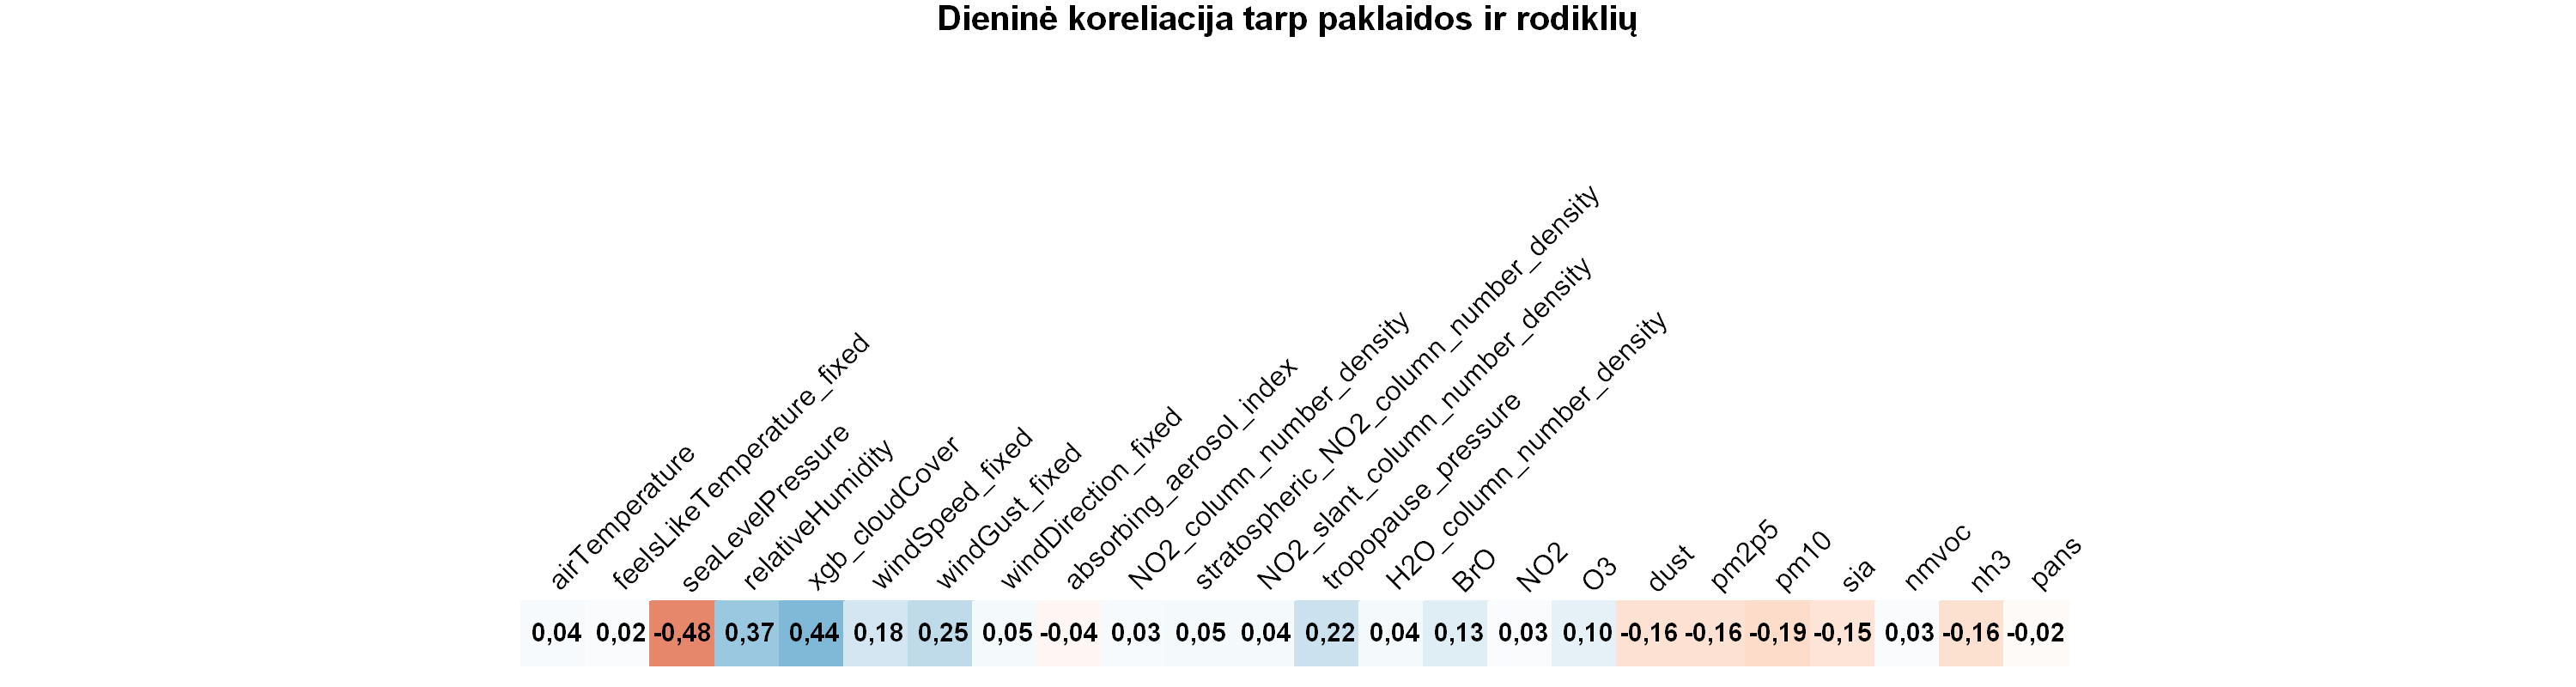

In [9]:
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 200)

plot_corr_1 <- as.matrix(t(cor_rez_day))
rownames(plot_corr_1) <- ""

# png(filename = "corr_heatmap_1.png", width = 17, height = 4.5, units = "in", res = 300)

options(OutDec = ",")
corrplot(plot_corr_1, method = 'color', addCoef.col = "black", tl.srt = 45, tl.col = 'black', tl.pos = 't', number.cex = 0.9, cl.pos = 'n', title = "Dieninė koreliacija tarp paklaidos ir rodiklių", mar = c(0,0,1,0))
options(OutDec = ".")

# dev.off()

In [10]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

col_names <- c(
  "airTemperature" = "Oro temperatūra",
  "feelsLikeTemperature_fixed" = "Juntamoji temperatūra",
  "seaLevelPressure" = "Slėgis jūros lygyje",
  "relativeHumidity" = "Santykinis oro drėgnis",
  "xgb_cloudCover" = "Debesuotumas",
  "windSpeed_fixed" = "Vėjo greitis",
  "windGust_fixed" = "Vėjo gūsis",
  "windDirection_fixed" = "Vėjo kryptis",
  "absorbing_aerosol_index" = "AAI",
  "NO2_column_number_density" = "NO2 VCD",
  "stratospheric_NO2_column_number_density" = "Stratosferos NO2 VCD",
  "NO2_slant_column_number_density" = "NO2 SCD",
  "tropopause_pressure" = "Tropopauzės slėgis",
  "H2O_column_number_density" = "H2O",
  "BrO" = "BrO VCD",
  "NO2" = "NO2 VCD",
  "O3" = "O3 VCD",
  "dust" = "Dulkės",
  "pm2p5" = "PM2,5",
  "pm10" = "PM10",
  "sia" = "PM2,5 SIA",
  "nmvoc" = "NMVOC",
  "nh3" = "NH3",
  "pans" = "PAN"
)

rownames(cor_rez_day) <- col_names

part1 <- as.matrix(cor_rez_day[1:8, , drop = FALSE])
part2 <- as.matrix(cor_rez_day[9:16, , drop = FALSE])
part3 <- as.matrix(cor_rez_day[17:24, , drop = FALSE])

colnames(part1) <- "Paklaida"; colnames(part2) <- "Paklaida"; colnames(part3) <- "Paklaida"

width_inch = 14 / 2.54
height_inch = width_inch * 0.6

png(filename = "corr_heatmap_1.png", width = width_inch, height = height_inch, units = "in", res = 300)
layout(matrix(c(1, 2, 3), 1, 3))
par(mfrow = c(1, 3), oma = c(0, 0, 4, 0))

options(OutDec = ",")

corrplot(part1, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex = 0.8, tl.cex = 0.8, tl.offset = 1)
corrplot(part2, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex = 0.8, tl.cex = 0.8, tl.offset = 1)
corrplot(part3, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex = 0.8, tl.cex = 0.8, tl.offset = 1)

mtext("Koreliacija tarp dieninės ECMWF paklaidos ir rodiklių", side = 3, line = 2, outer = TRUE, cex = 0.85, font = 1)

par(mfrow = c(1, 1))
options(OutDec = ".")

dev.off()

agg_record_164735262 
                   2

### Paklaidos mėnesiui

In [11]:
data_by_month <- data_clean %>%
    dplyr::select(-t2m, -tp, -tp_lag) %>%
    group_by(year = year(observationTime), month = month(observationTime)) %>%
    summarise(across(where(is.numeric), ~mean(., na.rm = TRUE)), .groups = "drop")
head(data_by_month)

year,month,airTemperature,feelsLikeTemperature_fixed,seaLevelPressure,relativeHumidity,xgb_cloudCover,windSpeed_fixed,windGust_fixed,windDirection_fixed,⋯,O3,dust,pm2p5,pm10,sia,nmvoc,nh3,pans,missforest_precipitation,tp_error
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2018,7,19.782222,19.83361111,1011.621,77.39444,61.43400,1.985833,9.106667,153.3000,⋯,325.8890,1.06237442,4.601026,5.652042,1.548626,3.585722,0.19122389,1.6584937,3.6733333,2.6259517
2018,8,19.148656,19.12238514,1016.927,71.29839,41.00312,2.005951,9.129032,190.0000,⋯,304.8510,0.09325709,4.798764,6.347528,2.258098,3.150768,0.51960494,1.6170481,1.7419355,2.7504680
2018,9,14.635694,14.21180556,1018.335,73.81667,50.09821,2.285833,9.126667,195.6333,⋯,297.2015,2.23112997,7.357725,11.413385,3.133960,3.261975,0.60311948,1.4149473,1.1200000,1.0561986
2018,10,8.083360,6.73062903,1017.771,82.20124,50.89922,2.825586,9.354839,174.8710,⋯,294.6680,0.29404332,6.242818,8.690252,3.243211,3.197375,0.29334225,1.0552586,1.3290323,0.5587336
2018,11,2.051250,-0.05652778,1027.381,91.02778,86.08711,2.671944,7.813333,155.7000,⋯,310.4006,1.48851305,8.132359,10.514413,4.479328,3.383899,0.07620617,1.0289202,0.5733333,0.5433934
2018,12,-1.481586,-4.78010753,1016.517,94.35215,94.00801,2.848253,8.132258,161.2581,⋯,318.7455,0.04485326,4.724880,6.197183,2.343671,4.634385,0.02553789,0.9796066,2.3741935,1.1422593


In [12]:
x_monthly <- data_by_month %>%
  dplyr::select(where(is.numeric)) %>%
  dplyr::select(-year, -month, -missforest_precipitation, -tp_error)

cor_rez_month <- cor(x_monthly, data_by_month$tp_error, use = "complete.obs", method = "spearman") 
cor_rez_month

airTemperature,0.64046823
feelsLikeTemperature_fixed,0.63139035
seaLevelPressure,-0.49695811
relativeHumidity,-0.26641185
xgb_cloudCover,-0.26031215
windSpeed_fixed,-0.39767479
windGust_fixed,0.04552495
windDirection_fixed,-0.04290492
absorbing_aerosol_index,-0.21925466
NO2_column_number_density,0.37383341
stratospheric_NO2_column_number_density,0.60033445


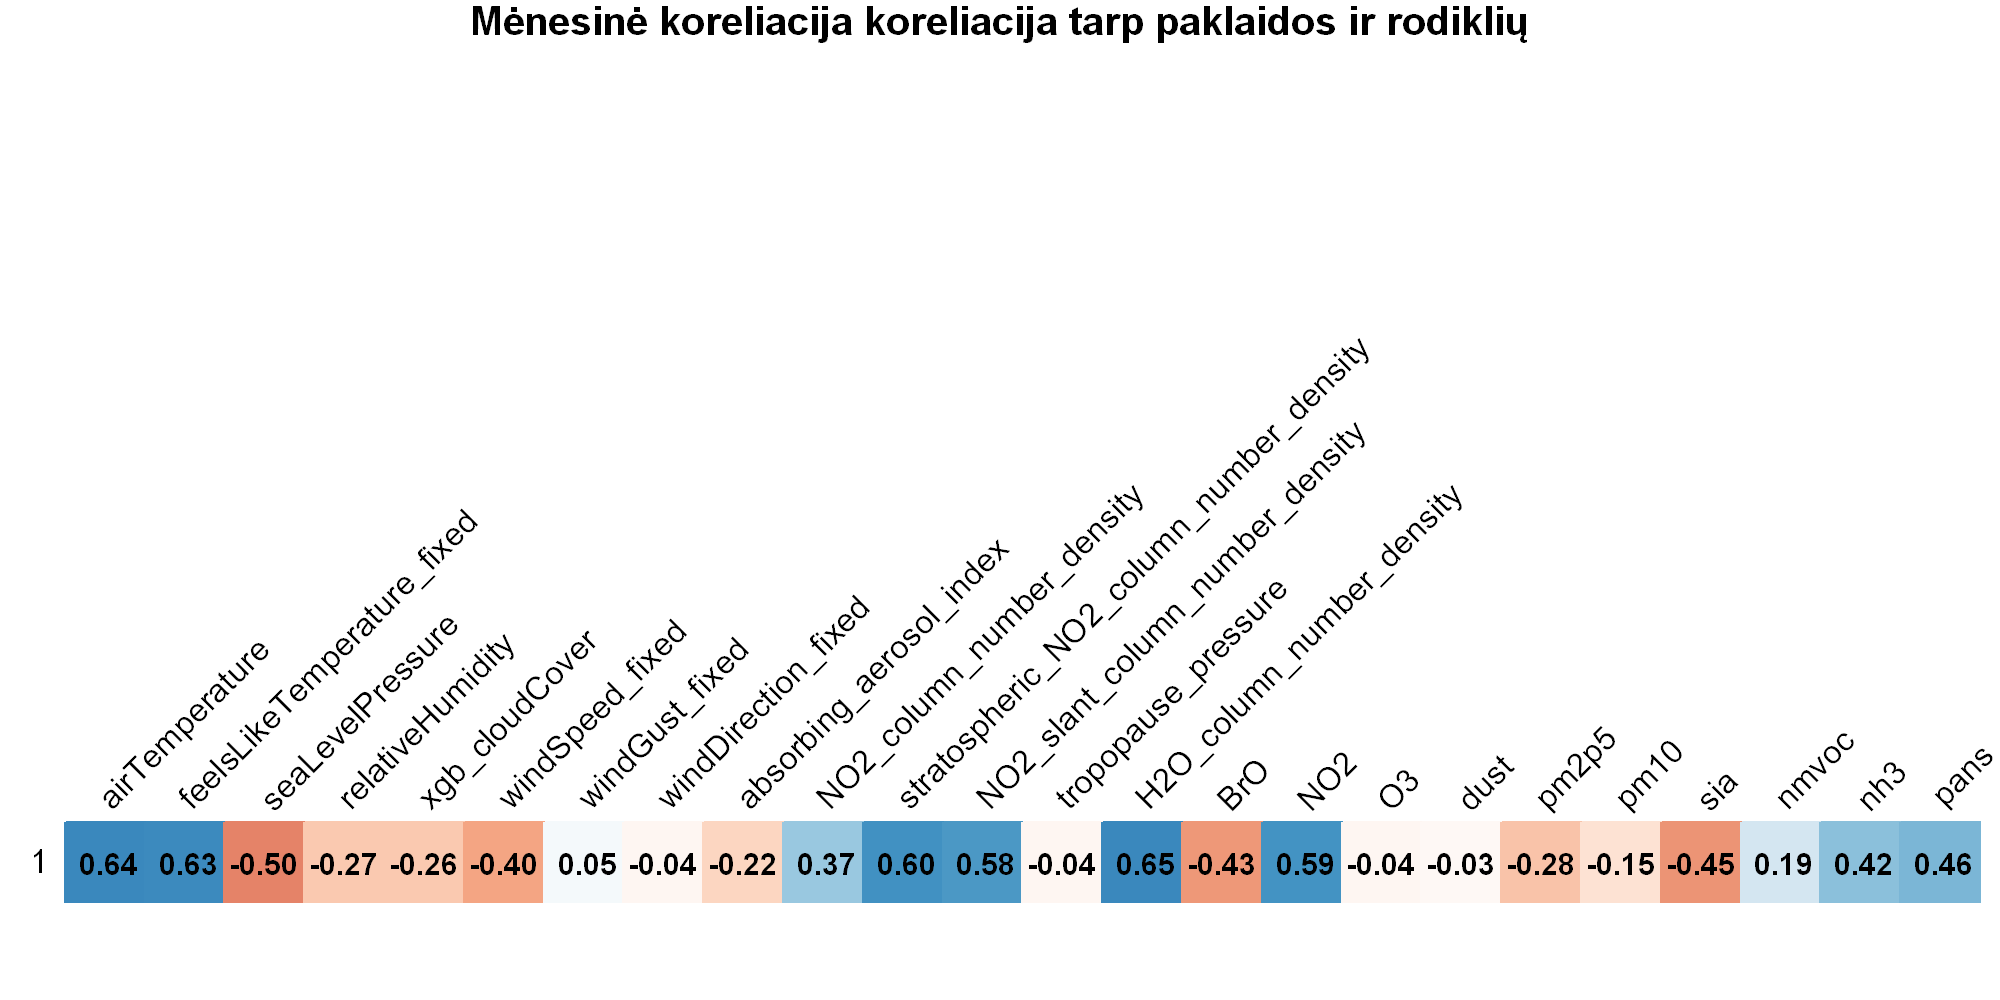

In [13]:
corrplot(t(cor_rez_month), method = 'color', addCoef.col = "black", tl.srt = 45, tl.col = 'black', number.cex = 0.9, cl.pos = 'n', title = "Mėnesinė koreliacija koreliacija tarp paklaidos ir rodiklių", mar = c(0,0,1,0))

## Koreliacija
### Koreliacija tarp visų kintamųjų

In [14]:
colnames(data_clean)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "tp"                                     
[27] "t2m"                                    
[28] "missforest_precipitation"               
[29] "tp_lag"                                 
[30] "tp_error"

In [15]:
numeric_columns <- data_clean %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(-tp, -tp_lag, -t2m, -tp_error)
    
corr <- cor(numeric_columns, use = "complete.obs", method = "spearman") 
View(corr)

,airTemperature,feelsLikeTemperature_fixed,seaLevelPressure,relativeHumidity,xgb_cloudCover,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,NO2_column_number_density,⋯,NO2,O3,dust,pm2p5,pm10,sia,nmvoc,nh3,pans,missforest_precipitation
airTemperature,1.000000000,0.995824697,-0.07042726,-0.48802994,-0.51152665,-0.28803980,-0.018803249,-0.09213059,-0.243054827,0.11357850,⋯,0.777419698,-0.30016130,0.37385405,0.103412156,0.22934763,-0.007459254,0.03246266,0.701286519,0.42516552,-0.083054679
feelsLikeTemperature_fixed,0.995824697,1.000000000,-0.04326567,-0.48757031,-0.51837919,-0.34833509,-0.070698683,-0.10144099,-0.241801642,0.11521276,⋯,0.782389129,-0.29976783,0.38035018,0.104530481,0.22598430,-0.001955907,0.03899521,0.702012356,0.43702736,-0.099248052
seaLevelPressure,-0.070427261,-0.043265669,1.00000000,-0.18744222,-0.25521012,-0.30220508,-0.340603455,-0.07758572,0.054193578,-0.05403978,⋯,-0.084988856,-0.17789335,0.21560023,0.167087542,0.17958916,0.165662353,-0.02773447,0.048824673,-0.01860081,-0.494077132
relativeHumidity,-0.488029942,-0.487570312,-0.18744222,1.00000000,0.75084382,0.13281332,-0.096957544,0.05229742,0.173552621,-0.10993739,⋯,-0.596847265,-0.16520773,-0.22215228,-0.049410859,-0.18778751,0.014112639,0.16136721,-0.636719886,-0.38994471,0.473859312
xgb_cloudCover,-0.511526650,-0.518379185,-0.25521012,0.75084382,1.00000000,0.26944451,0.071882896,0.05359728,0.175732436,-0.07458338,⋯,-0.537927734,0.05440836,-0.23415513,-0.111655322,-0.23217448,-0.043949469,0.12138282,-0.610502558,-0.32722755,0.474000491
windSpeed_fixed,-0.288039796,-0.348335091,-0.30220508,0.13281332,0.26944451,1.00000000,0.805879906,0.19726902,0.078917952,-0.07869724,⋯,-0.309262734,0.08761409,-0.19532991,-0.058570726,-0.04402627,-0.047472240,-0.13346192,-0.247931857,-0.32351834,0.220749460
windGust_fixed,-0.018803249,-0.070698683,-0.34060345,-0.09695754,0.07188290,0.80587991,1.000000000,0.17276303,-0.049882674,-0.05569840,⋯,-0.006583225,0.14235877,-0.15746586,-0.151510173,-0.08963501,-0.165351382,-0.24150292,-0.006643722,-0.14590113,0.267996484
windDirection_fixed,-0.092130590,-0.101440995,-0.07758572,0.05229742,0.05359728,0.19726902,0.172763026,1.00000000,0.018317066,-0.10302289,⋯,-0.045444640,0.11055540,-0.25082562,-0.269842077,-0.21518676,-0.225304840,-0.26083060,-0.019563511,-0.18379246,0.058109762
absorbing_aerosol_index,-0.243054827,-0.241801642,0.05419358,0.17355262,0.17573244,0.07891795,-0.049882674,0.01831707,1.000000000,-0.04154731,⋯,-0.290866842,-0.06783807,-0.02961612,-0.066284969,-0.04488685,0.016953107,0.18020389,-0.192332730,-0.22136902,0.007253333
NO2_column_number_density,0.113578504,0.115212757,-0.05403978,-0.10993739,-0.07458338,-0.07869724,-0.055698395,-0.10302289,-0.041547313,1.00000000,⋯,0.260510188,0.11025427,0.13013031,0.165764159,0.10994015,0.144669223,0.30396846,0.072151376,0.19894893,-0.010390022


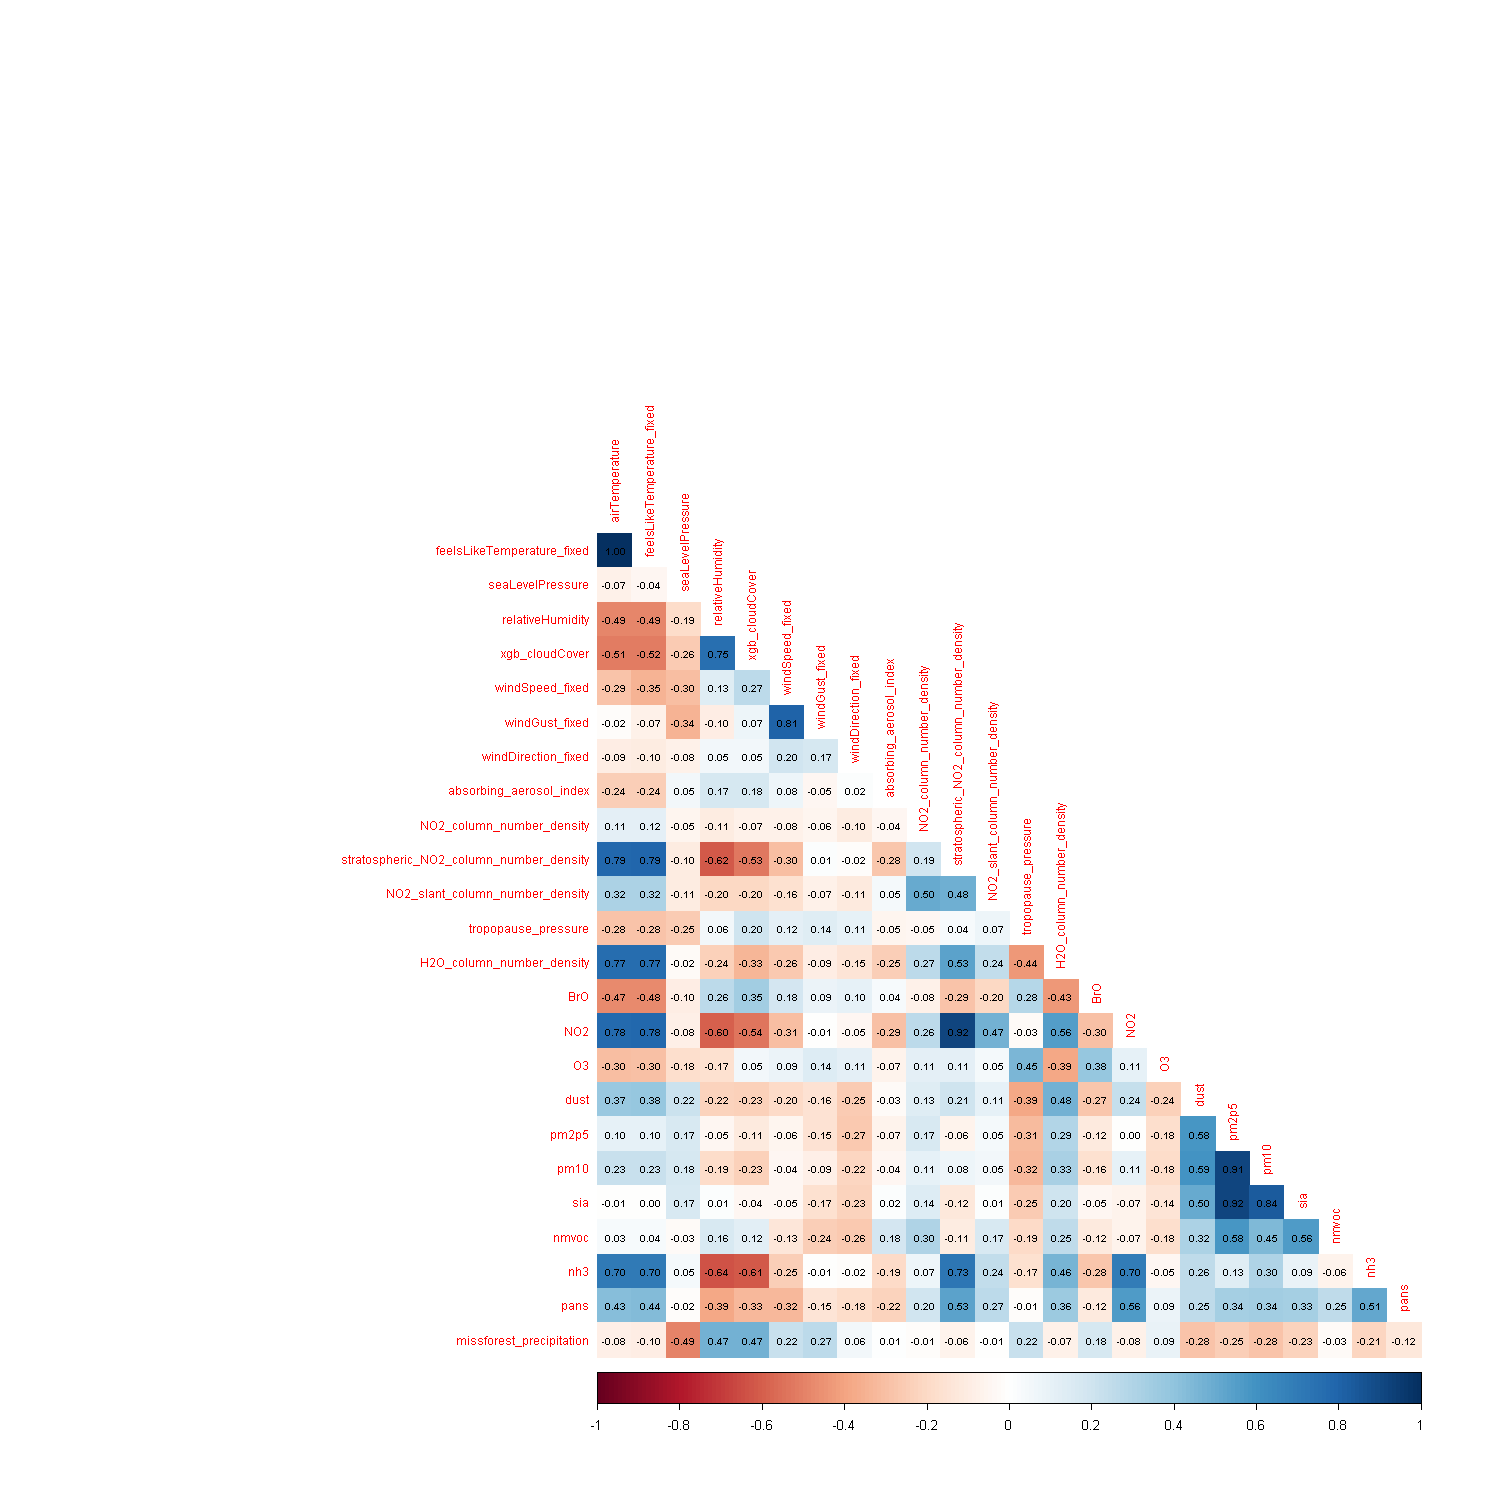

In [16]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)

corrplot(corr, method = "color", type = "lower",addCoef.col = "black", number.cex = 0.6, tl.cex = 0.7, diag = FALSE)

### Koreliacija tarp kritulių ir visų kintamųjų

In [17]:
x <- data_clean %>%
    dplyr::select(where(is.numeric)) %>%
    dplyr::select(-missforest_precipitation, -tp, -t2m, -tp_lag, -tp_error)

corr_missforest_precipitation <- cor(x, data_clean$missforest_precipitation, use = "complete.obs", method = "spearman") 
corr_missforest_precipitation

airTemperature,-0.083054679
feelsLikeTemperature_fixed,-0.099248052
seaLevelPressure,-0.494077132
relativeHumidity,0.473859312
xgb_cloudCover,0.474000491
windSpeed_fixed,0.220749460
windGust_fixed,0.267996484
windDirection_fixed,0.058109762
absorbing_aerosol_index,0.007253333
NO2_column_number_density,-0.010390022
stratospheric_NO2_column_number_density,-0.062281840


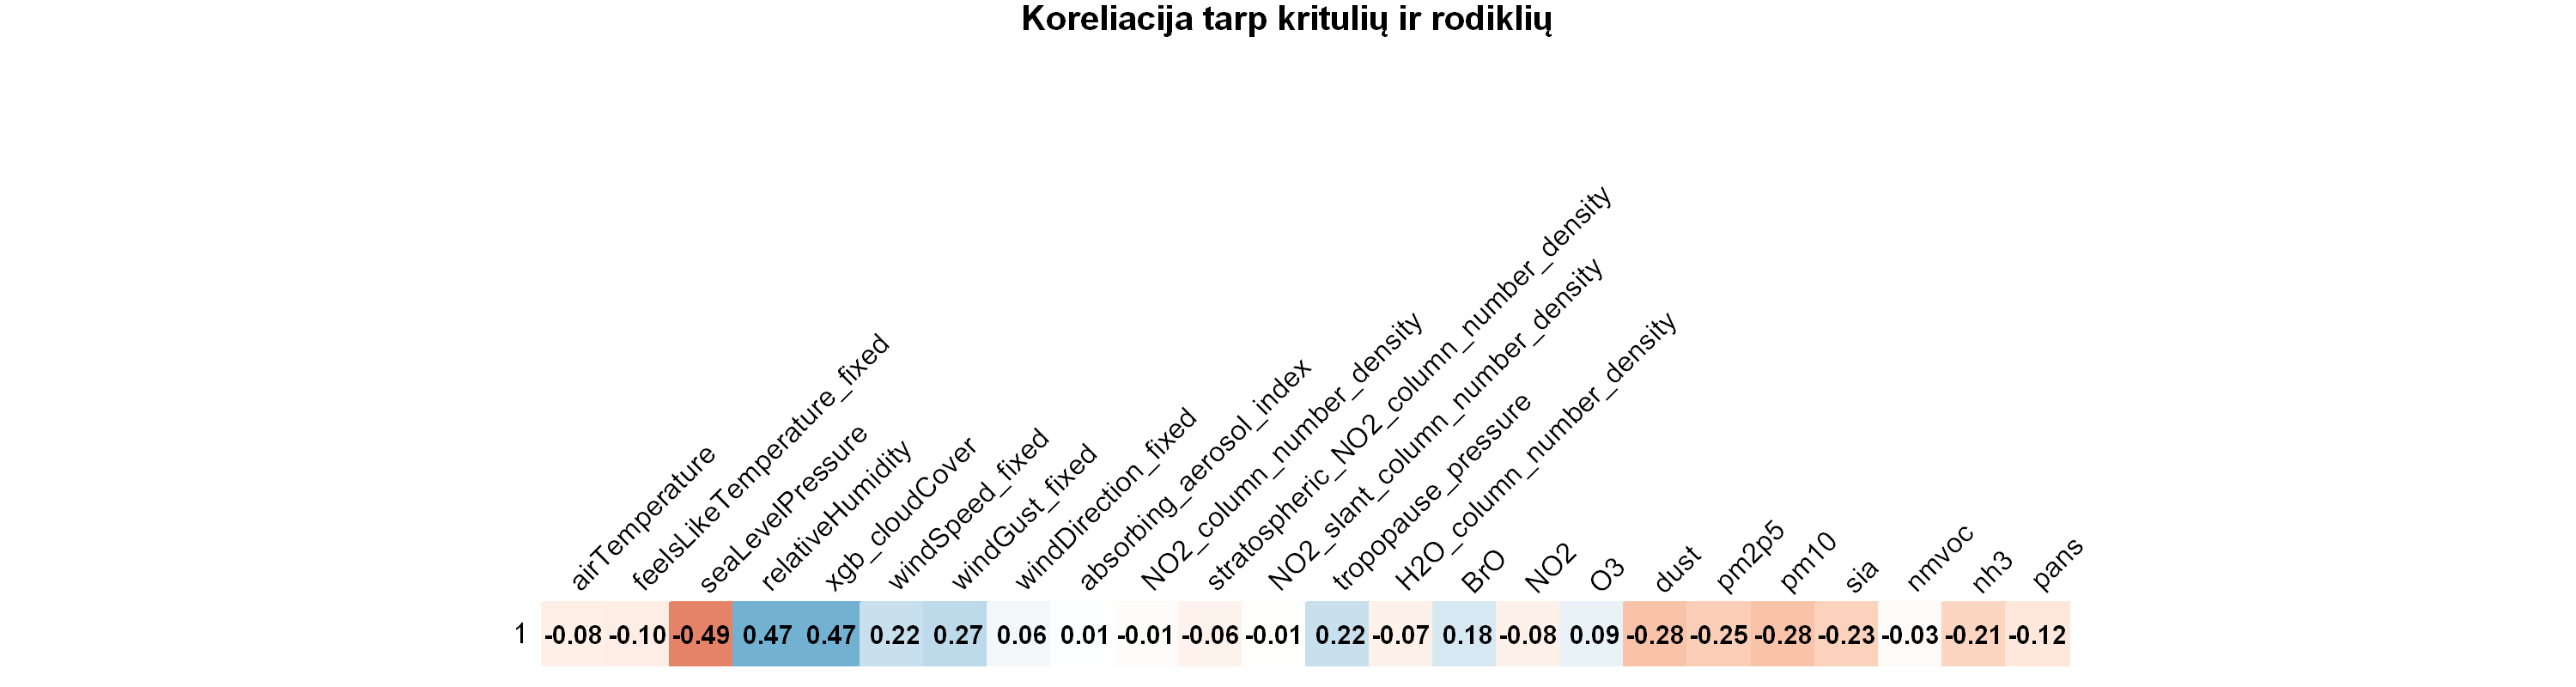

In [18]:
options(repr.plot.width = 15, repr.plot.height = 4, repr.plot.res = 200)
corrplot(t(corr_missforest_precipitation), method = 'color', addCoef.col = "black", tl.srt = 45, number.cex = 0.9, tl.col = 'black', cl.pos = 'n', title = "Koreliacija tarp kritulių ir rodiklių", mar = c(0,0,1,0))

In [19]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

width_inch = 14 / 2.54
height_inch = width_inch * 0.55

rownames(corr_missforest_precipitation) <- col_names

part1 <- as.matrix(corr_missforest_precipitation[1:8, , drop = FALSE])
part2 <- as.matrix(corr_missforest_precipitation[9:16, , drop = FALSE])
part3 <- as.matrix(corr_missforest_precipitation[17:24, , drop = FALSE])

colnames(part1) <- "Krituliai"; colnames(part2) <- "Krituliai"; colnames(part3) <- "Krituliai"

png(filename = "corr_heatmap_2.png", width = width_inch, height = height_inch, units = "in", res = 300)
layout(matrix(c(1, 2, 3), 1, 3))
par(mfrow = c(1, 3), oma = c(0, 0, 4, 0))

options(OutDec = ",")

corrplot(part1, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=0.8, tl.cex = 0.8, tl.offset = 1)
corrplot(part2, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=0.8, tl.cex = 0.8, tl.offset = 1)
corrplot(part3, method='color', addCoef.col="black", tl.col='black', tl.srt=0, tl.pos='lt', cl.pos='n', number.cex=0.8, tl.cex = 0.8, tl.offset = 1)

mtext("Koreliacija tarp kritulių ir kitų rodiklių", side = 3, line = 2, outer = TRUE, cex = 0.85, font = 1)

par(mfrow = c(1, 1))
options(OutDec = ".")

dev.off()

agg_record_1417266707 
                    2

### Dalinės koreliacijos

In [20]:
colnames(data_clean)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "tp"                                     
[27] "t2m"                                    
[28] "missforest_precipitation"               
[29] "tp_lag"                                 
[30] "tp_error"

In [21]:
all_variables_pcor <- pcor(numeric_columns, method = 'spearman')
all_variables_pcor

,airTemperature,feelsLikeTemperature_fixed,seaLevelPressure,relativeHumidity,xgb_cloudCover,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,NO2_column_number_density,⋯,NO2,O3,dust,pm2p5,pm10,sia,nmvoc,nh3,pans,missforest_precipitation
airTemperature,1.000000000,0.983380658,-0.099734405,-0.0288763162,-0.01797204,0.4454999081,-0.051103533,-0.021157145,-0.013253905,-0.048975217,⋯,-0.0151717687,-0.004123013,-0.02662075,0.025019071,0.081739774,-0.139025608,0.0018365592,0.064923102,0.026168554,0.048345031
feelsLikeTemperature_fixed,0.983380658,1.000000000,0.068648497,0.0164341170,0.01868482,-0.4625535403,0.058869850,0.017634852,0.017639876,0.022965265,⋯,0.0541409677,-0.067148663,0.03883407,-0.013650519,-0.067946599,0.103906847,0.0049085313,-0.030086009,-0.038965994,-0.039022907
seaLevelPressure,-0.099734405,0.068648497,1.000000000,-0.1041743384,-0.04217707,-0.1076039257,-0.043645959,-0.003254273,0.032529424,0.019386267,⋯,0.0083982609,-0.170797308,0.08419493,0.018305669,0.026991156,-0.007311708,-0.1302965659,0.007340010,-0.053296205,-0.229657739
relativeHumidity,-0.028876316,0.016434117,-0.104174338,1.0000000000,0.45271080,-0.0255960471,-0.169885389,0.113199542,-0.036748435,-0.116409797,⋯,-0.0004506775,-0.214981070,-0.07431386,0.004920798,-0.027482612,0.069267204,-0.0002160174,-0.142291577,-0.098662605,0.382037461
xgb_cloudCover,-0.017972040,0.018684820,-0.042177069,0.4527108049,1.00000000,0.1050023405,-0.021582827,-0.023488697,0.030878128,0.034495593,⋯,-0.0947797355,0.076035004,0.10452227,-0.039050871,-0.020595910,0.017584858,0.0976293095,-0.137432147,0.059403410,0.143271487
windSpeed_fixed,0.445499908,-0.462553540,-0.107603926,-0.0255960471,0.10500234,1.0000000000,0.737922423,0.104392242,0.037266622,0.033285200,⋯,0.0080891457,-0.089405350,-0.02784934,0.010013782,0.027411299,0.063409486,-0.0071921507,-0.025719520,-0.141989374,-0.100532309
windGust_fixed,-0.051103533,0.058869850,-0.043645959,-0.1698853893,-0.02158283,0.7379224233,1.000000000,-0.020569835,-0.030474506,-0.016745009,⋯,0.0043485998,0.039971659,0.01684012,-0.009346157,0.001506669,-0.032415094,-0.0910582259,-0.004775926,0.042954096,0.228835840
windDirection_fixed,-0.021157145,0.017634852,-0.003254273,0.1131995415,-0.02348870,0.1043922424,-0.020569835,1.000000000,0.022618960,0.015440829,⋯,0.0103401078,0.049473167,-0.10002201,-0.080108443,0.032295259,0.043807154,-0.0690151965,0.063823052,-0.078630553,-0.079695290
absorbing_aerosol_index,-0.013253905,0.017639876,0.032529424,-0.0367484355,0.03087813,0.0372666225,-0.030474506,0.022618960,1.000000000,-0.078225477,⋯,-0.0547415355,-0.009529398,0.11291629,-0.293709894,0.150866357,0.143101103,0.2900529545,0.037482713,-0.076973637,0.018523450
NO2_column_number_density,-0.048975217,0.022965265,0.019386267,-0.1164097971,0.03449559,0.0332852000,-0.016745009,0.015440829,-0.078225477,1.000000000,⋯,0.1504129475,0.133418007,-0.01920384,-0.008888933,-0.025294989,0.013358867,0.1887464722,-0.002456748,-0.031328273,0.036965737


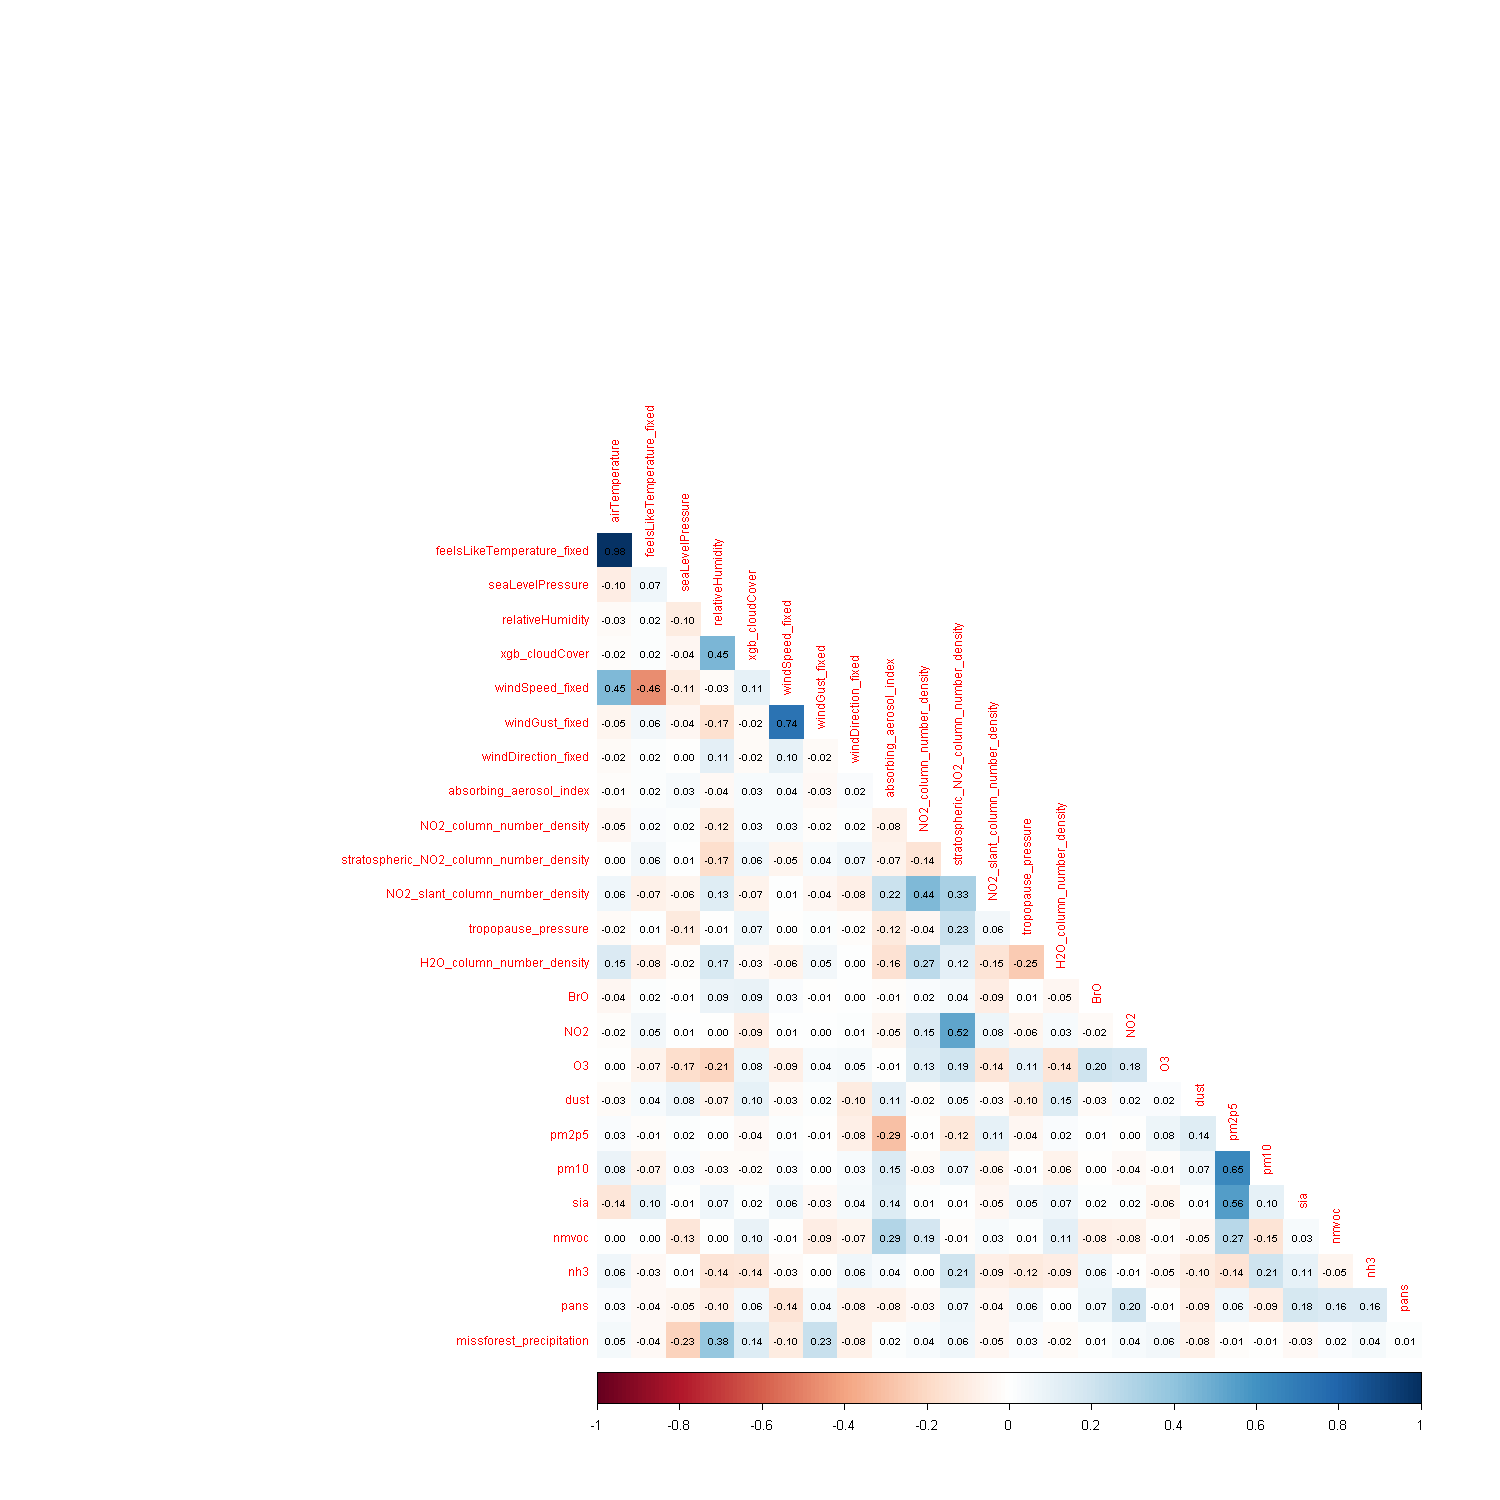

In [22]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)

corrplot(all_variables_pcor$estimate, method = "color", type = "lower", addCoef.col = "black", number.cex = 0.6, tl.cex = 0.7, diag = FALSE)

### Kryžminė koreliacija

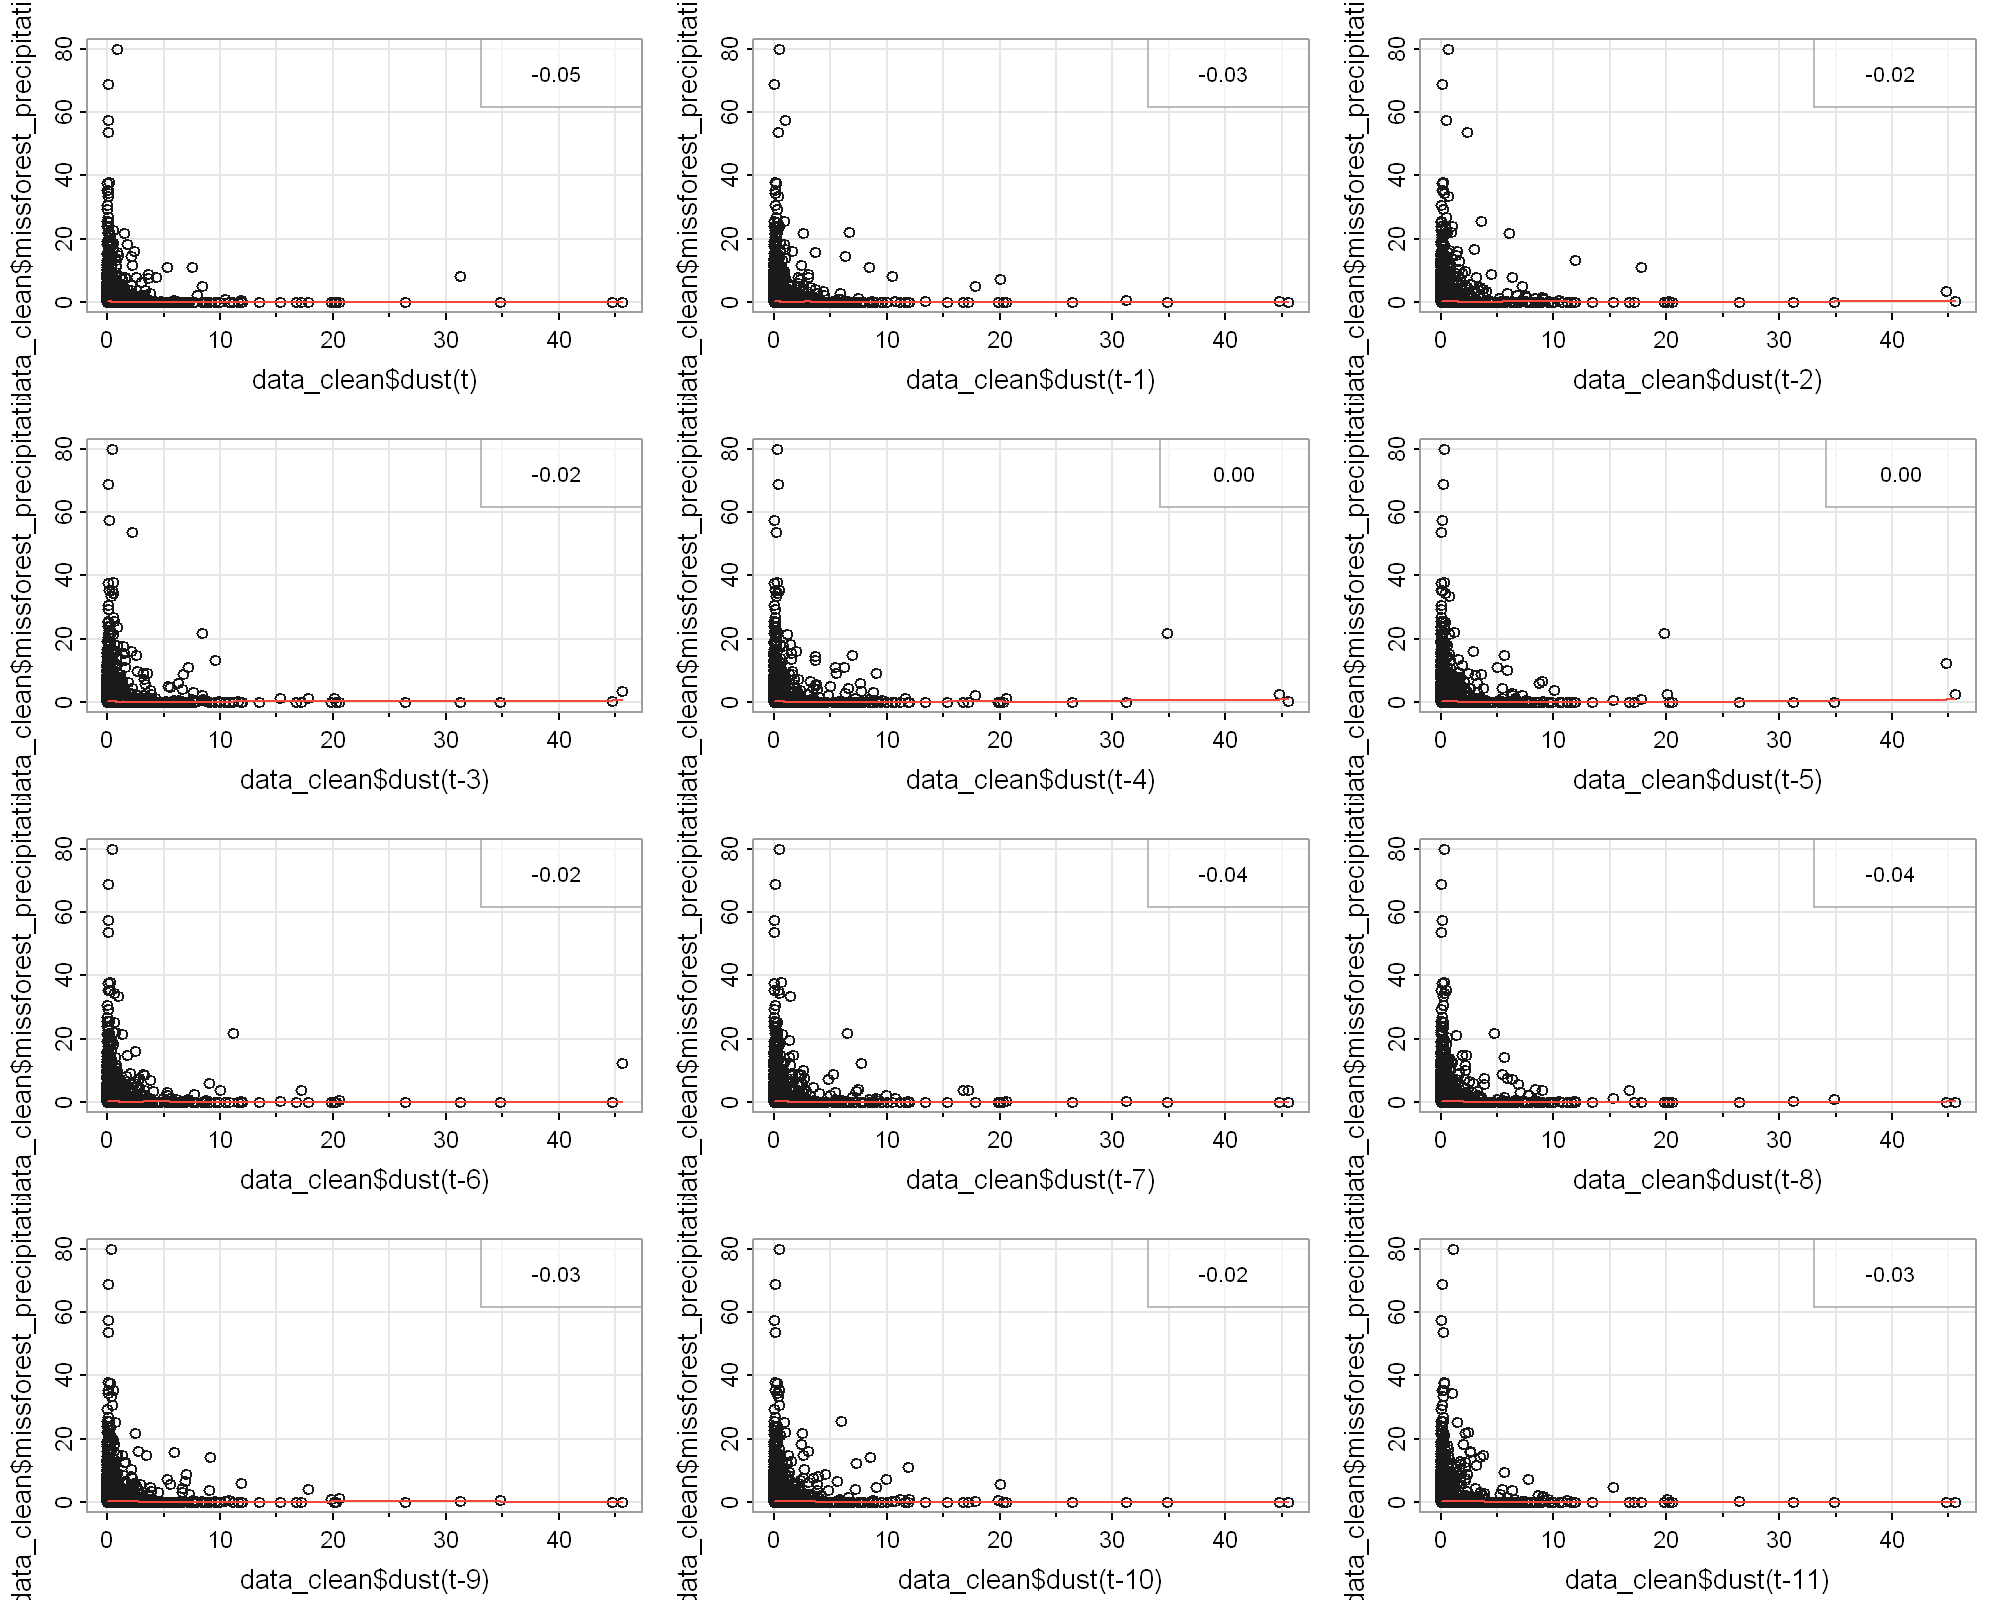

In [23]:
options(repr.plot.width = 10, repr.plot.height = 8, repr.plot.res = 200)

astsa::lag2.plot(data_clean$dust, data_clean$missforest_precipitation, 11)

In [24]:
colnames(data_clean)

[1] "observationTime"                        
 [2] "airTemperature"                         
 [3] "feelsLikeTemperature_fixed"             
 [4] "seaLevelPressure"                       
 [5] "relativeHumidity"                       
 [6] "xgb_cloudCover"                         
 [7] "windSpeed_fixed"                        
 [8] "windGust_fixed"                         
 [9] "windDirection_fixed"                    
[10] "absorbing_aerosol_index"                
[11] "NO2_column_number_density"              
[12] "stratospheric_NO2_column_number_density"
[13] "NO2_slant_column_number_density"        
[14] "tropopause_pressure"                    
[15] "H2O_column_number_density"              
[16] "BrO"                                    
[17] "NO2"                                    
[18] "O3"                                     
[19] "dust"                                   
[20] "pm2p5"                                  
[21] "pm10"                                   
[22] "sia"                                    
[23] "nmvoc"                                  
[24] "nh3"                                    
[25] "pans"                                   
[26] "tp"                                     
[27] "t2m"                                    
[28] "missforest_precipitation"               
[29] "tp_lag"                                 
[30] "tp_error"

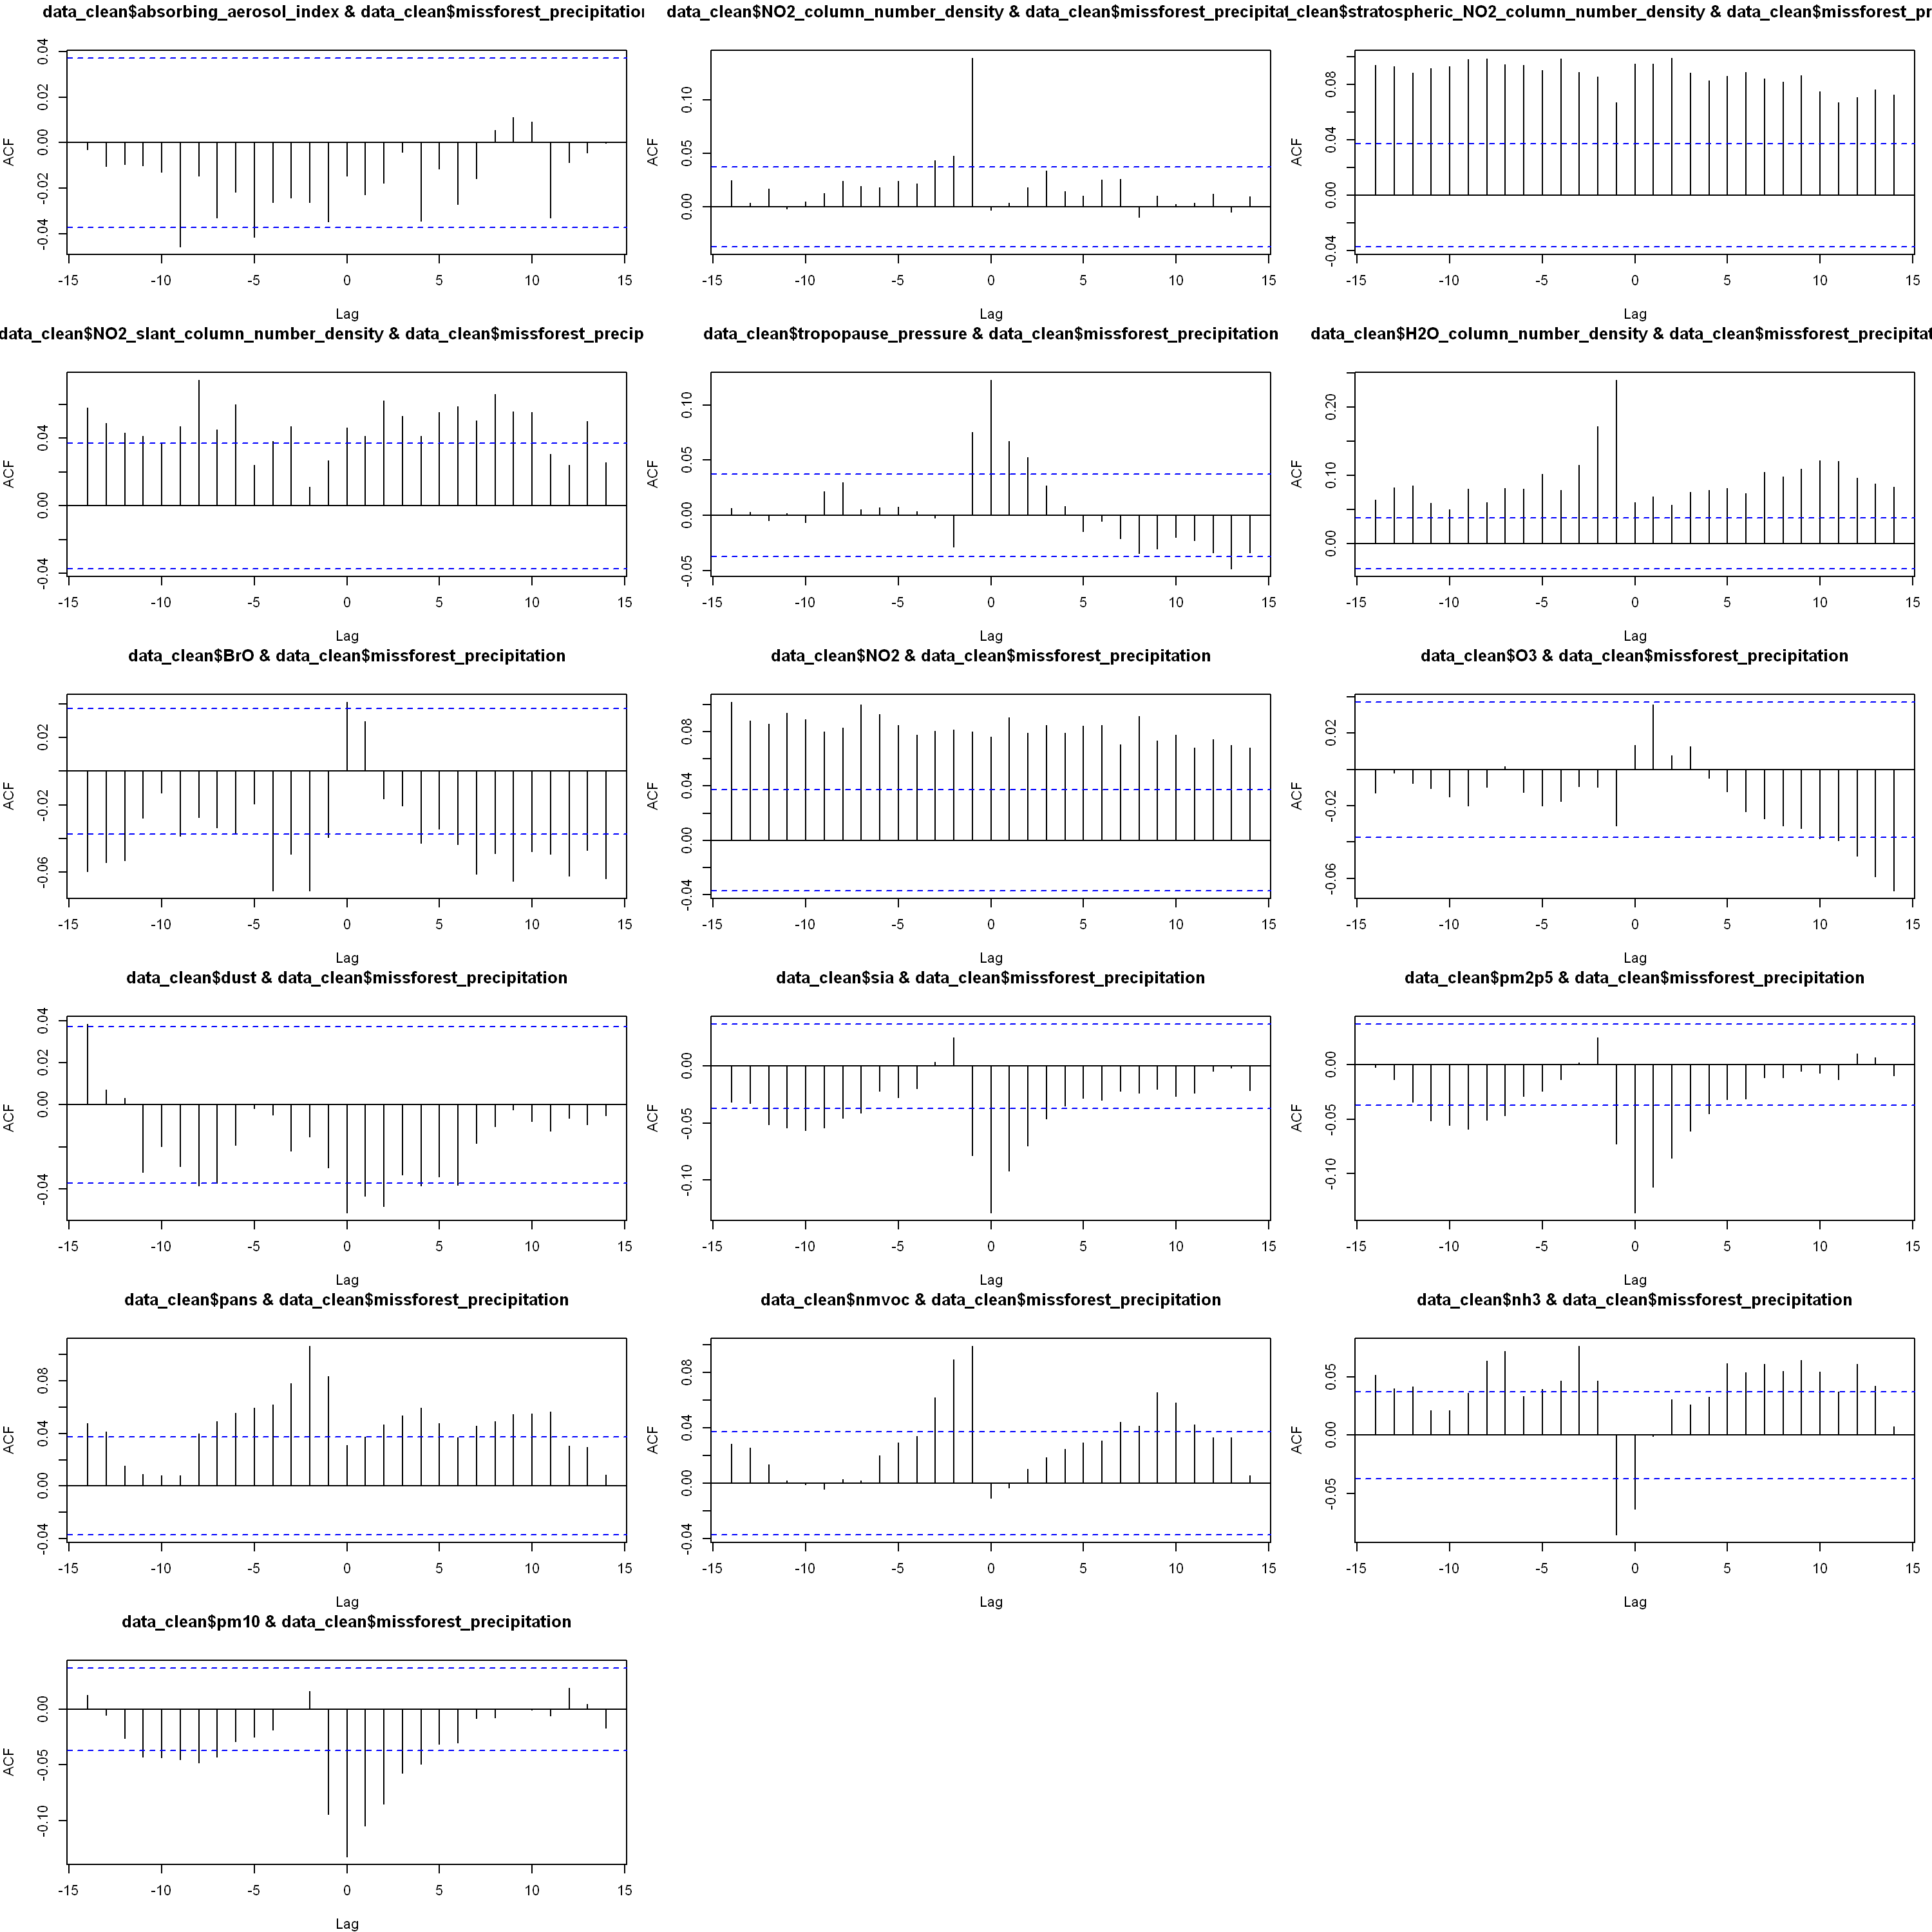

In [25]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 200)
par(mfrow = c(6, 3), mar = c(4, 4, 3, 1))

ccf(data_clean$absorbing_aerosol_index, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$NO2_column_number_density, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$stratospheric_NO2_column_number_density, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$NO2_slant_column_number_density, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$tropopause_pressure, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$H2O_column_number_density, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$BrO, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$NO2, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$O3, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$dust, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$sia, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$pm2p5, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$pans, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$nmvoc, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$nh3, data_clean$missforest_precipitation, lag.max = 14)
ccf(data_clean$pm10, data_clean$missforest_precipitation, lag.max = 14)

par(mfrow = c(1, 1))


Autocorrelations of series 'X', by lag

   -14    -13    -12    -11    -10     -9     -8     -7     -6     -5     -4 
 0.028  0.026  0.014  0.002 -0.001 -0.004  0.003  0.002  0.020  0.029  0.034 
    -3     -2     -1      0      1      2      3      4      5      6      7 
 0.062  0.089  0.099 -0.011 -0.003  0.010  0.019  0.025  0.029  0.031  0.044 
     8      9     10     11     12     13     14 
 0.041  0.065  0.058  0.042  0.033  0.033  0.006 


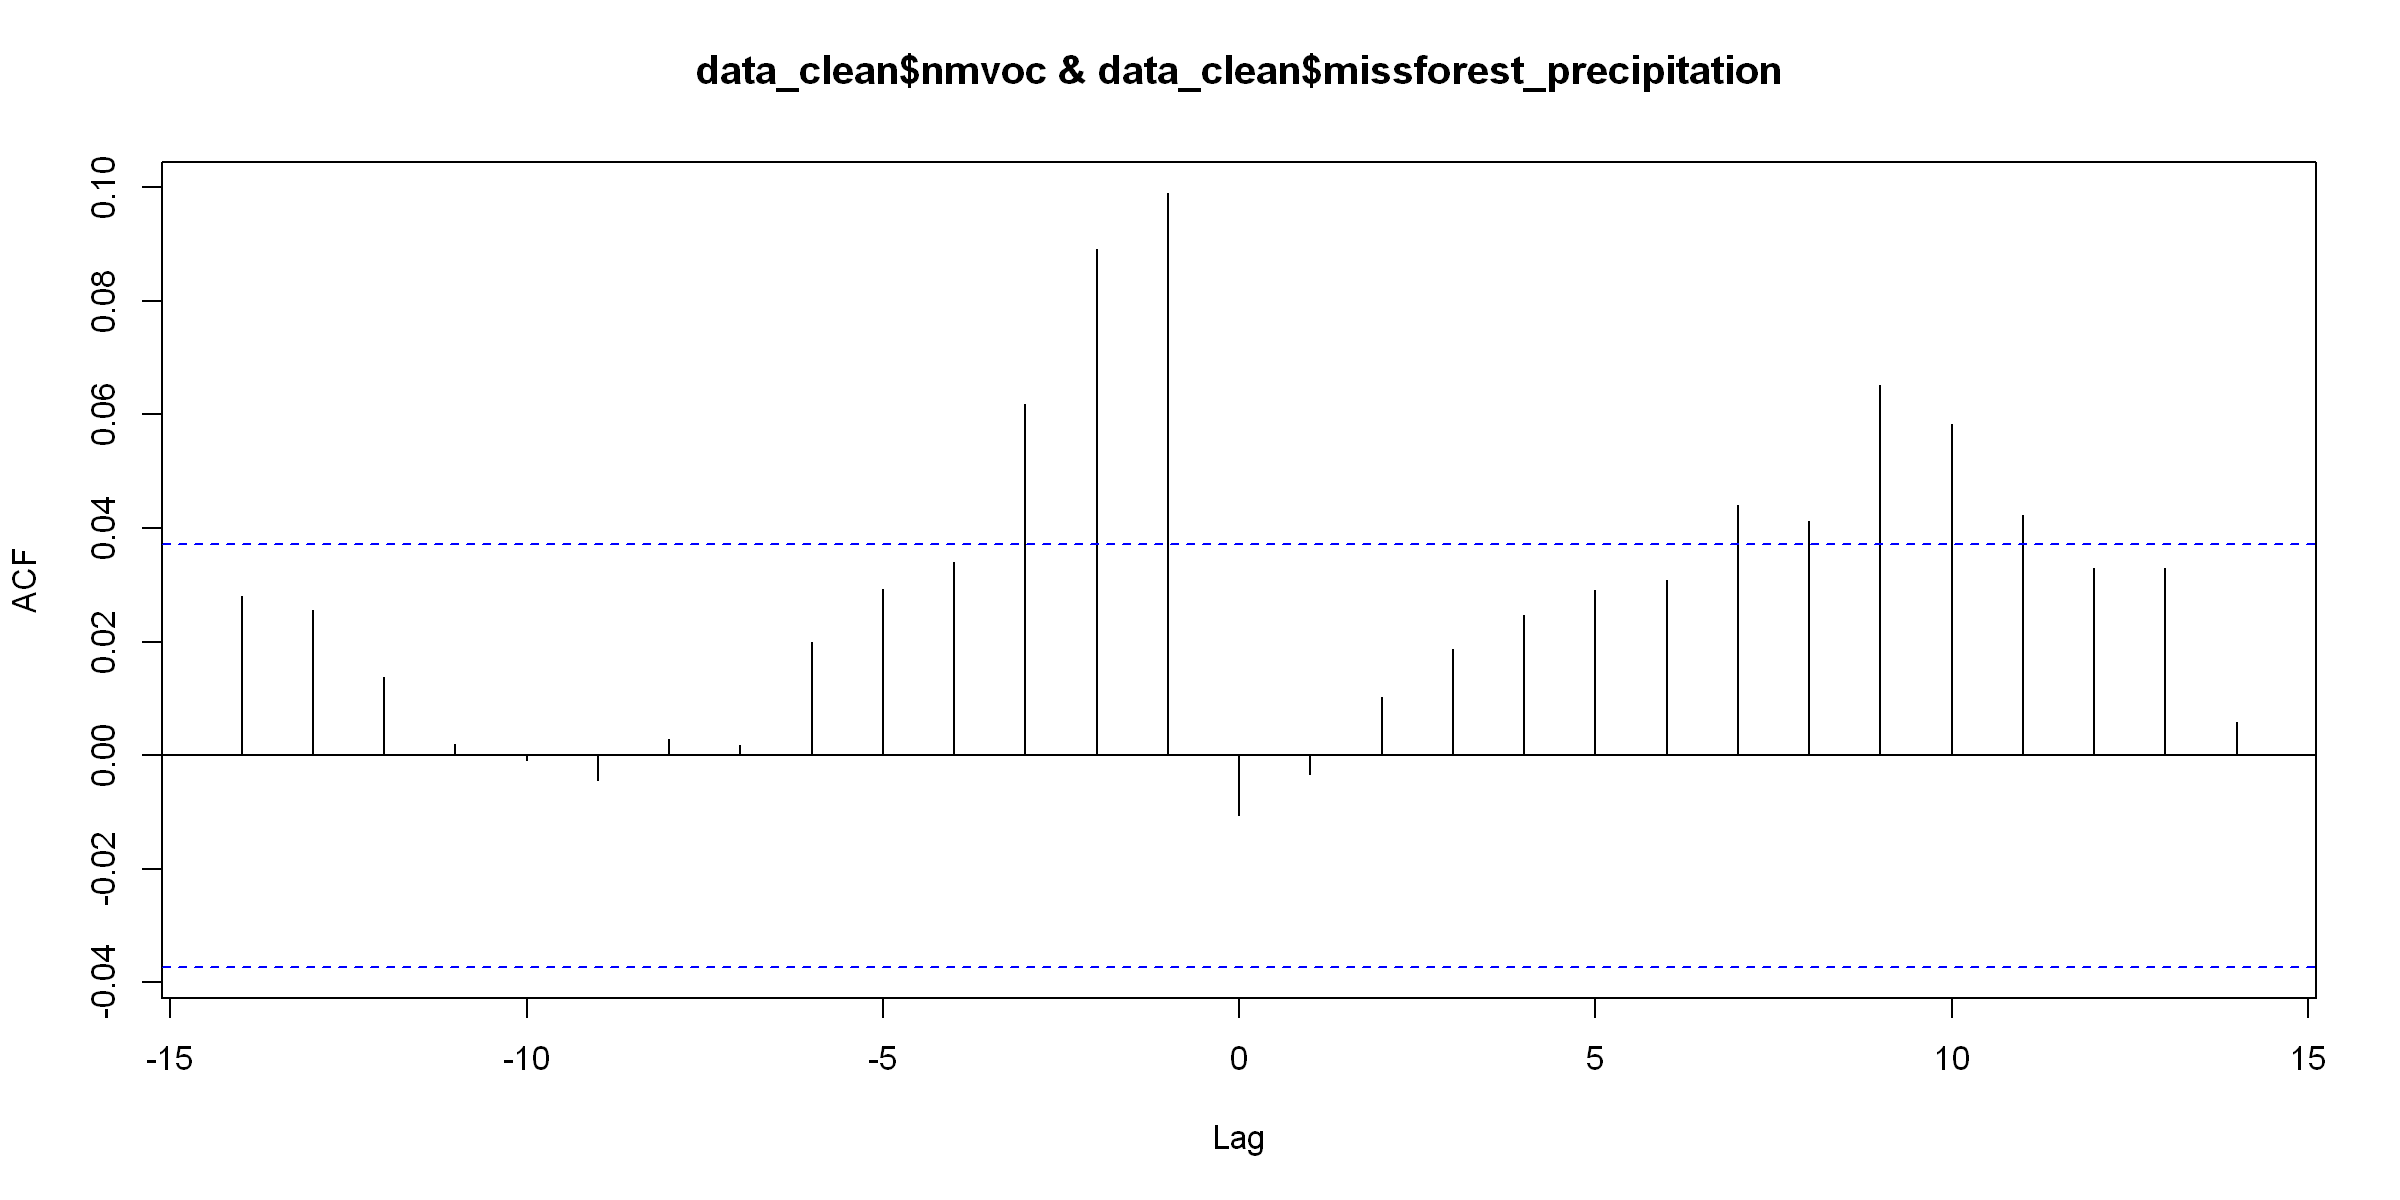

In [26]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)
print(ccf(data_clean$nmvoc, data_clean$missforest_precipitation, lag.max = 14))

   Lag          r_P     lower_P    upper_P          r_S     lower_S    upper_S
1   -7  0.001807650 -0.03946176 0.03946176  0.028958072 -0.04535095 0.04535095
2   -6  0.019971364 -0.03887342 0.03887342  0.030312345 -0.04453695 0.04453695
3   -5  0.029208740 -0.03985585 0.03985585  0.049650776 -0.04570008 0.04570008
4   -4  0.033991081 -0.04124305 0.04124305  0.060270021 -0.04611235 0.04611235
5   -3  0.061795345 -0.04001886 0.04001886  0.075467170 -0.04440520 0.04440520
6   -2  0.089177916 -0.03906825 0.03906825  0.112017565 -0.04545418 0.04545418
7   -1  0.099028491 -0.04064808 0.04064808  0.172582673 -0.04465896 0.04465896
8    0 -0.010540397 -0.03866271 0.03866271 -0.025151466 -0.04407398 0.04407398
9    1 -0.003285189 -0.03923688 0.03923688 -0.008671092 -0.04544078 0.04544078
10   2  0.010218093 -0.03965721 0.03965721  0.012251934 -0.04588002 0.04588002
11   3  0.018723330 -0.03933692 0.03933692  0.043031111 -0.04545363 0.04545363
12   4  0.024614505 -0.03796038 0.03796038  0.067201

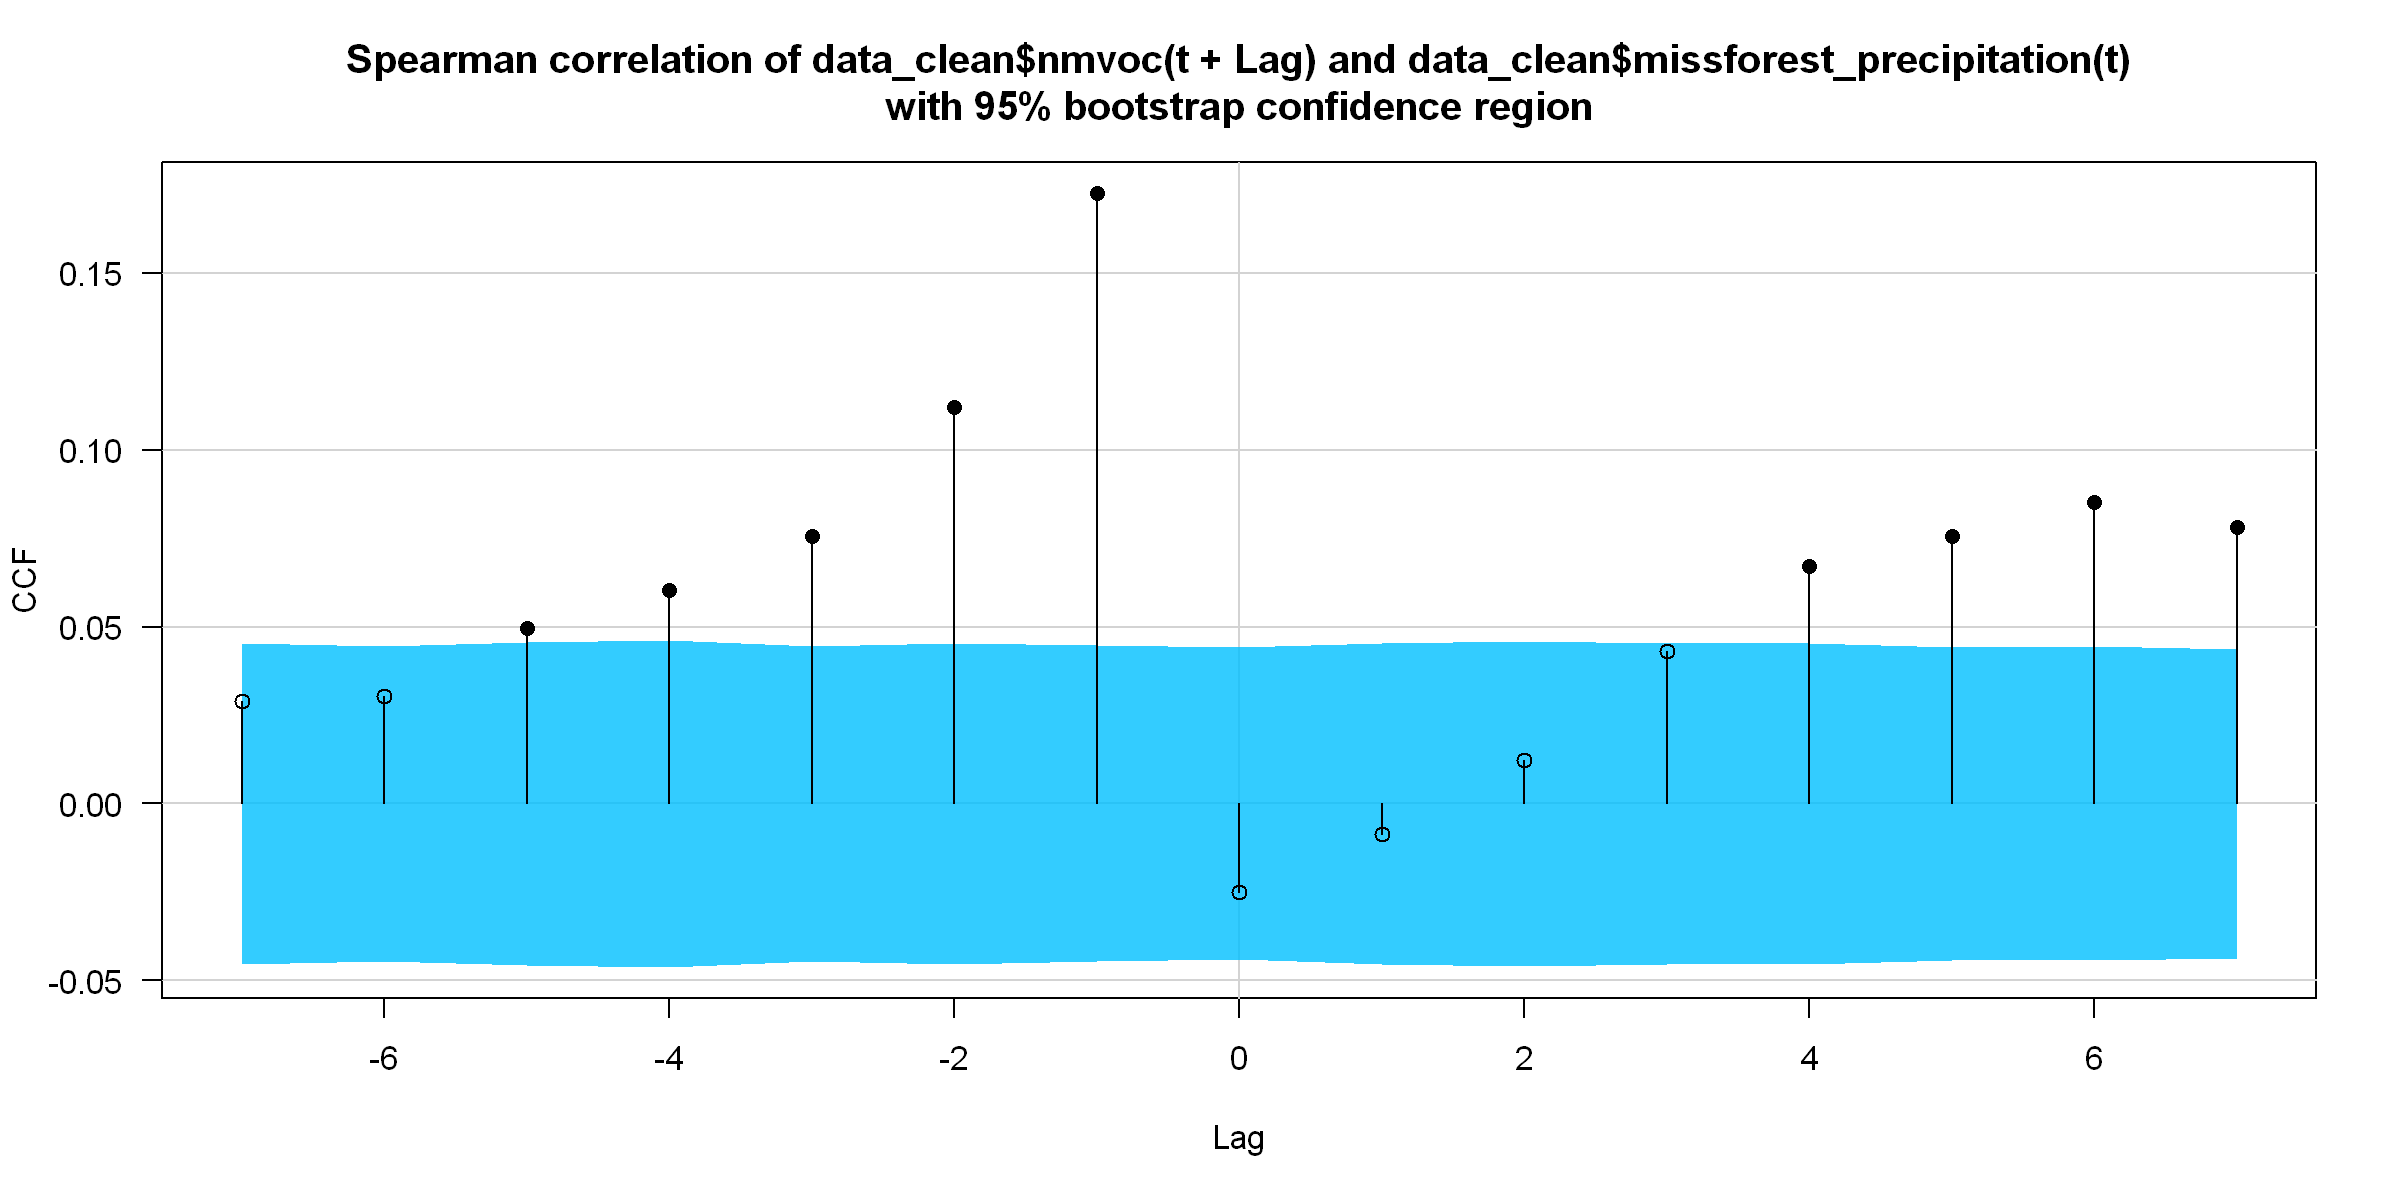

In [29]:
print(ccf_boot(data_clean$nmvoc, data_clean$missforest_precipitation, lag.max = 7, plot = "Spearman"))


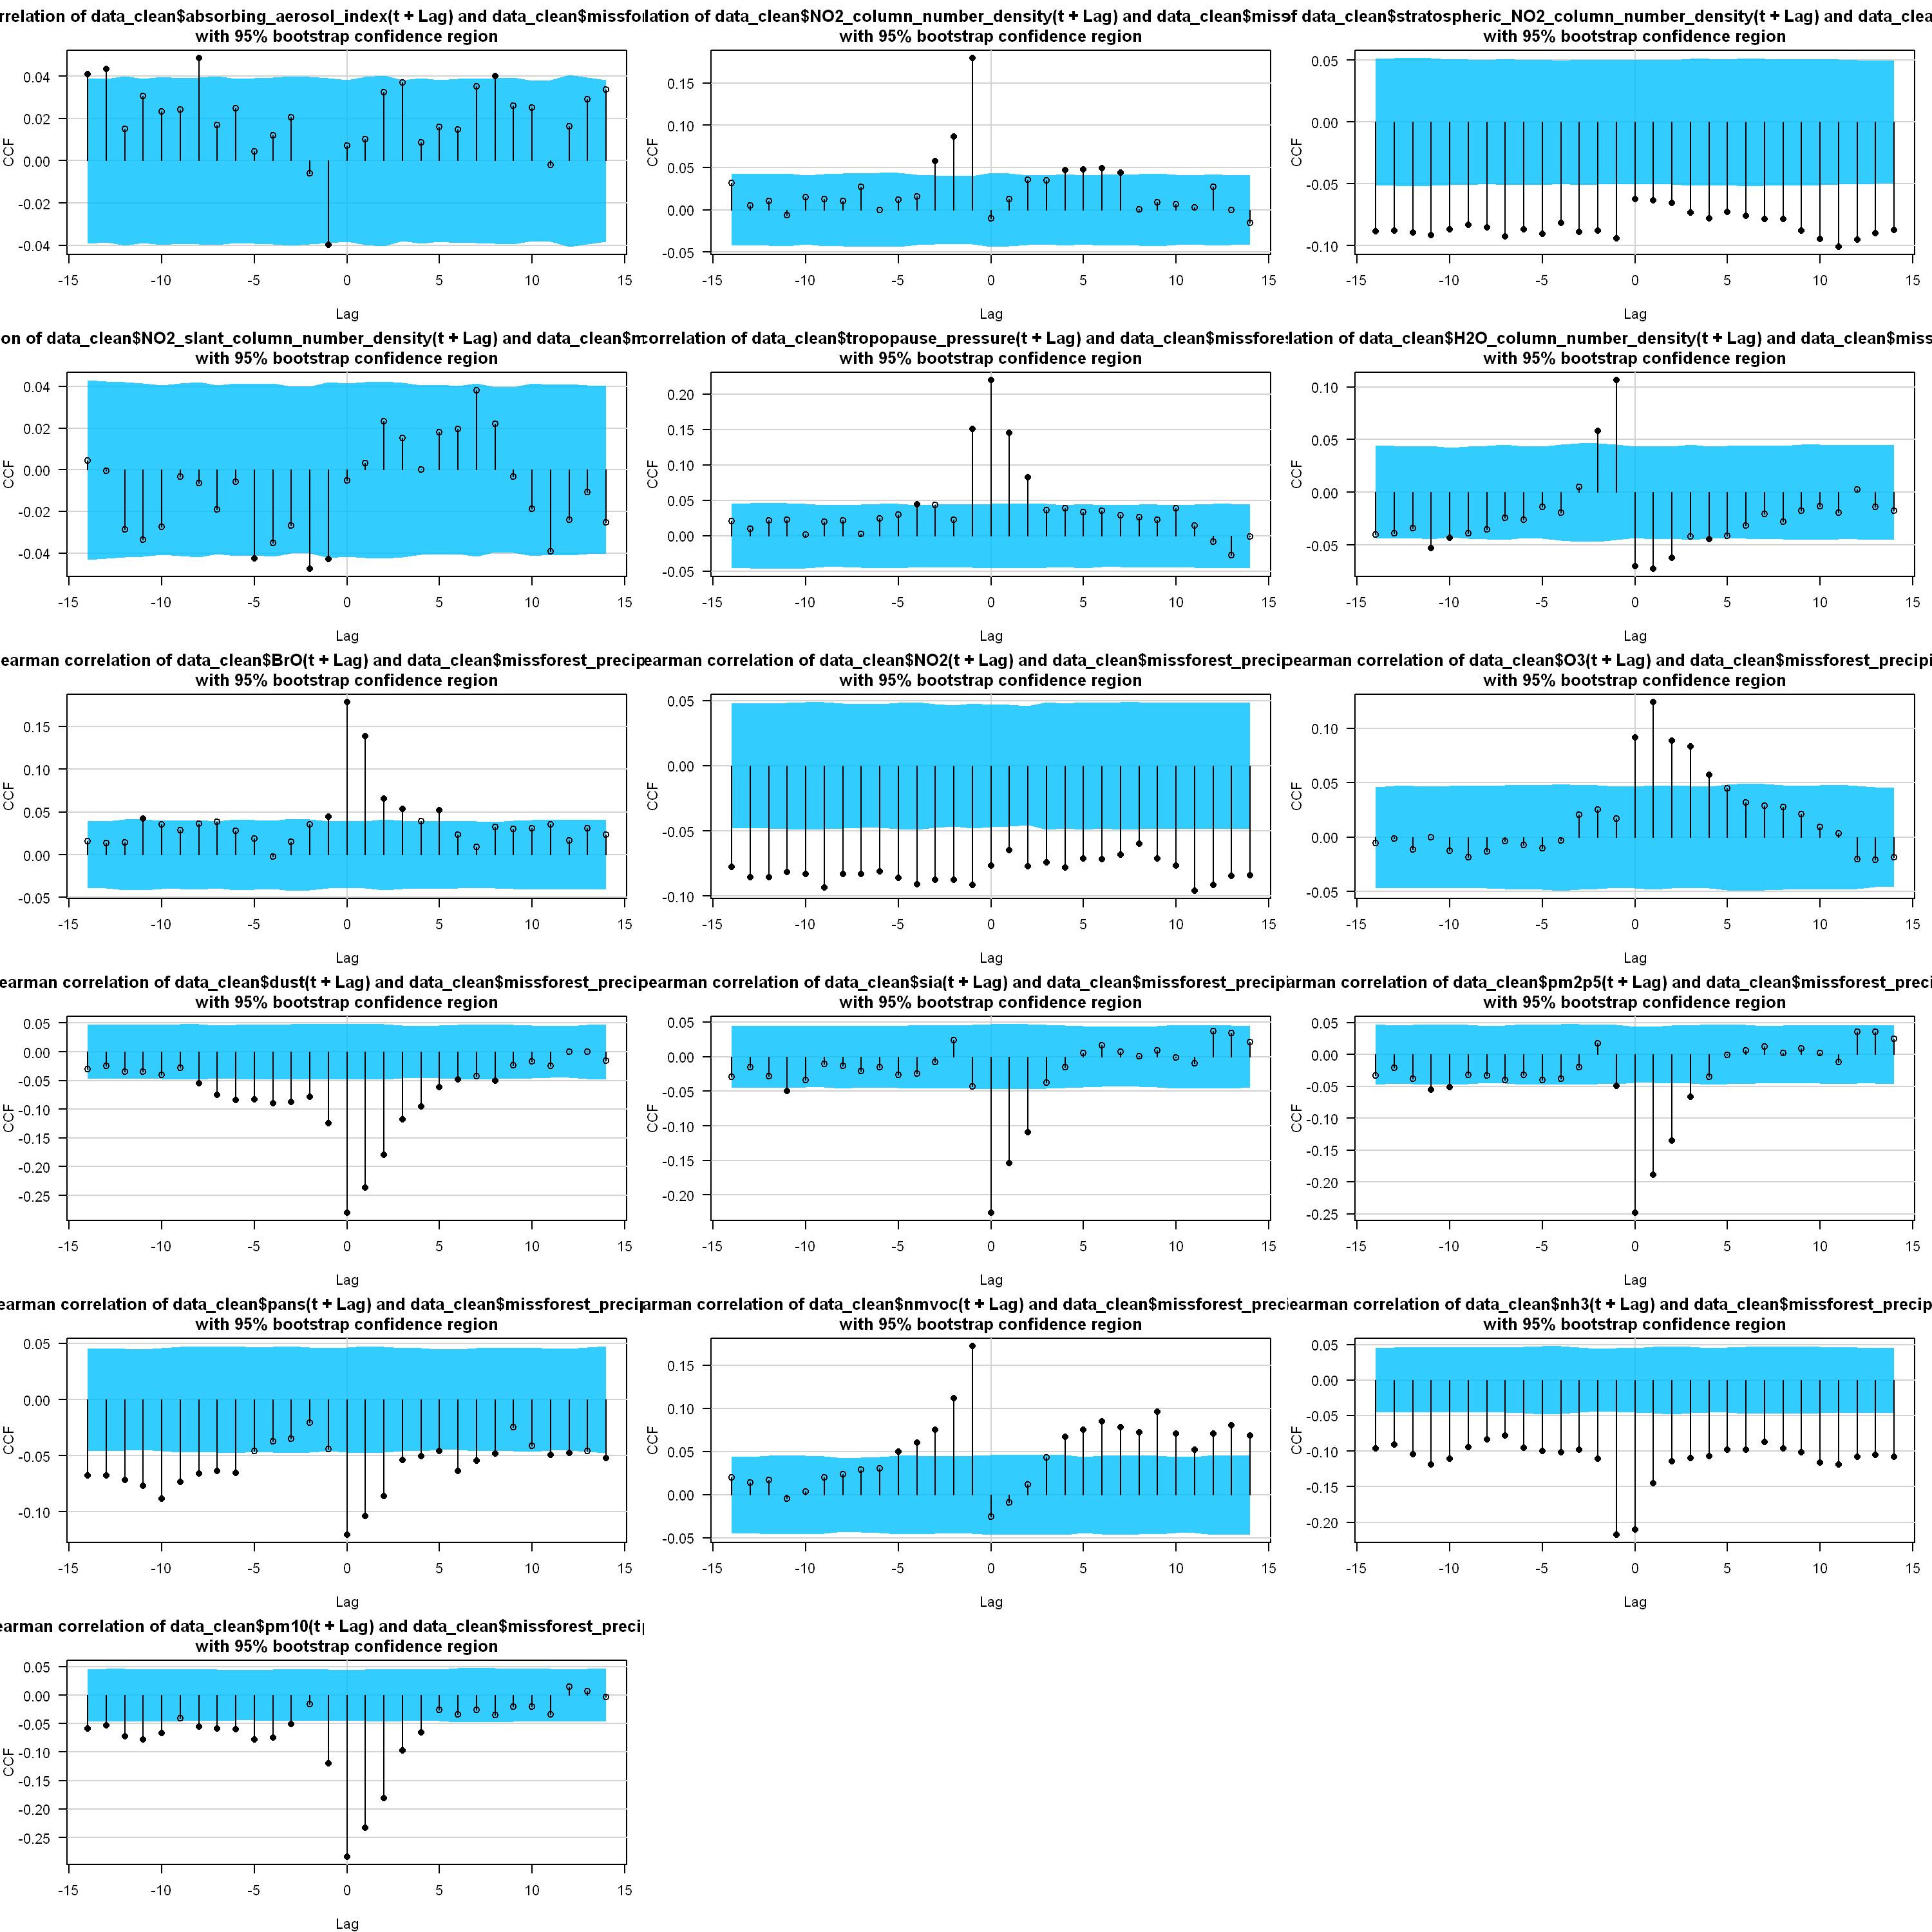

In [30]:
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 200)
par(mfrow = c(6, 3), mar = c(4, 4, 3, 1))

ccf_boot(data_clean$absorbing_aerosol_index, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$NO2_column_number_density, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$stratospheric_NO2_column_number_density, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$NO2_slant_column_number_density, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$tropopause_pressure, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$H2O_column_number_density, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$BrO, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$NO2, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$O3, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$dust, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$sia, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$pm2p5, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$pans, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$nmvoc, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$nh3, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")
ccf_boot(data_clean$pm10, data_clean$missforest_precipitation, lag.max = 14, plot = "Spearman")

par(mfrow = c(1, 1))

In [31]:
options(repr.plot.width = 12, repr.plot.height = 6, repr.plot.res = 200)

width_inch = 17 / 2.54
height_inch = width_inch * 0.75

png(filename = "cross_corr.png", width = width_inch, height = height_inch, units = "in", res = 300)
par(mfrow = c(3, 3), mar = c(3, 3, 3, 1), oma = c(2, 5, 4, 2))


plot_ccf_custom <- function(x, y, pavadinimas) {
  res <- ccf(x, y, lag.max = 14, plot = FALSE)
  
  plot(res, main = "", yaxt = 'n', ylab = "", cex.axis = 1, cex.lab = 1)
  title(main = pavadinimas, cex.main = 1.0)
  
  y_ticks <- axTicks(2)
  y_labels <- gsub("\\.", ",", sprintf("%.2f", y_ticks))

  axis(2, at = y_ticks, labels = y_labels, las = 1, cex.axis = 1)
}

plot_ccf_custom(data_clean$NO2_column_number_density, data_clean$missforest_precipitation, "NO2 VCD")
plot_ccf_custom(data_clean$BrO, data_clean$missforest_precipitation, "BrO VCD")
plot_ccf_custom(data_clean$H2O_column_number_density, data_clean$missforest_precipitation, "H2O")
plot_ccf_custom(data_clean$sia, data_clean$missforest_precipitation, "PM2,5 SIA")
plot_ccf_custom(data_clean$pm2p5, data_clean$missforest_precipitation, "PM2,5")
plot_ccf_custom(data_clean$pans, data_clean$missforest_precipitation, "PAN")
plot_ccf_custom(data_clean$nmvoc, data_clean$missforest_precipitation, "NMVO")
plot_ccf_custom(data_clean$nh3, data_clean$missforest_precipitation, "NH3")
plot_ccf_custom(data_clean$pm10, data_clean$missforest_precipitation, "PM10")

mtext("Kryžminės koreliacijos koeficientas", side = 2, line = 2, outer = TRUE, cex = 0.85)
mtext("Kryžminė koreliacija tarp kritulių ir taršos elementų", side = 3, line = 2, outer = TRUE, cex = 1.05)
par(mfrow = c(1, 1))

dev.off()

agg_record_1570371206 
                    2

In [32]:
library(funtimes)

width_inch = 17 / 2.54
height_inch = width_inch * 0.8

png(filename = "cross_corr_NEW.png", width = width_inch, height = height_inch, units = "in", res = 300)
# par(mfrow = c(3, 3), mar = c(4, 4, 3, 1), oma = c(2, 5, 4, 2))
par(mfrow = c(3, 3), mar = c(2.5, 3.5, 2, 0.5), oma = c(4, 4, 3, 1))

plot_ccf_custom <- function(x, y, name) {
  boot_res <- ccf_boot(x, y, lag.max = 14, plot = "none", B = 1000)
  
  lags <- boot_res$Lag
  rS <- boot_res$r_S
  lower <- boot_res$lower_S
  upper <- boot_res$upper_S

  y_min <- min(lower, rS) * 1.1
  y_max <- max(upper, rS) * 1.1

  plot(lags, rS, type = "n", ylim = c(y_min, y_max),
       xaxt = 'n', yaxt = 'n', xlab = "", ylab = "", main = "")

  grid(nx = NA, ny = NULL, col = "gray90", lty = "dotted")
  
  lines(lags, lower, col = "blue", lty = 2)
  lines(lags, upper, col = "blue", lty = 2)
  abline(h = 0, col = "grey")
  
  segments(lags, 0, lags, rS, lwd = 1)
  
  significant <- rS > upper | rS < lower
  points(lags[significant], rS[significant], pch = 21, bg = "orange", cex = 0.85)
  
  axis(1, at = seq(-14, 14, by = 7), cex.axis = 1)
  # x_ticks <- seq(-14, 14, by = 4, cex.axis = 1)
  y_ticks <- axTicks(2)
  y_labels <- gsub("\\.", ",", sprintf("%.2f", y_ticks))
  axis(2, at = y_ticks, labels = y_labels, las = 1, cex.axis = 1)
  
  title(main = name, cex.main = 1)
}

plot_ccf_custom(data_clean$NO2_column_number_density, data_clean$missforest_precipitation, "NO2 VCD")
plot_ccf_custom(data_clean$BrO, data_clean$missforest_precipitation, "BrO VCD")
plot_ccf_custom(data_clean$H2O_column_number_density, data_clean$missforest_precipitation, "H2O")
plot_ccf_custom(data_clean$dust, data_clean$missforest_precipitation, "Dulkės")
plot_ccf_custom(data_clean$pm2p5, data_clean$missforest_precipitation, "PM2,5")
plot_ccf_custom(data_clean$pans, data_clean$missforest_precipitation, "PAN")
plot_ccf_custom(data_clean$nmvoc, data_clean$missforest_precipitation, "NMVO")
plot_ccf_custom(data_clean$nh3, data_clean$missforest_precipitation, "NH3")
plot_ccf_custom(data_clean$pm10, data_clean$missforest_precipitation, "PM10")

mtext("Spearman kryžminės koreliacijos koeficientas", side = 2, line = 2, outer = TRUE, cex = 0.85)
mtext("Vėlavimas (angl. lag)", side = 1, line = 2, outer = TRUE, cex = 0.85)
mtext("Kryžminė koreliacija", side = 3, line = 1, outer = TRUE, cex = 1.05)

dev.off()

agg_record_128120387 
                   2

-----

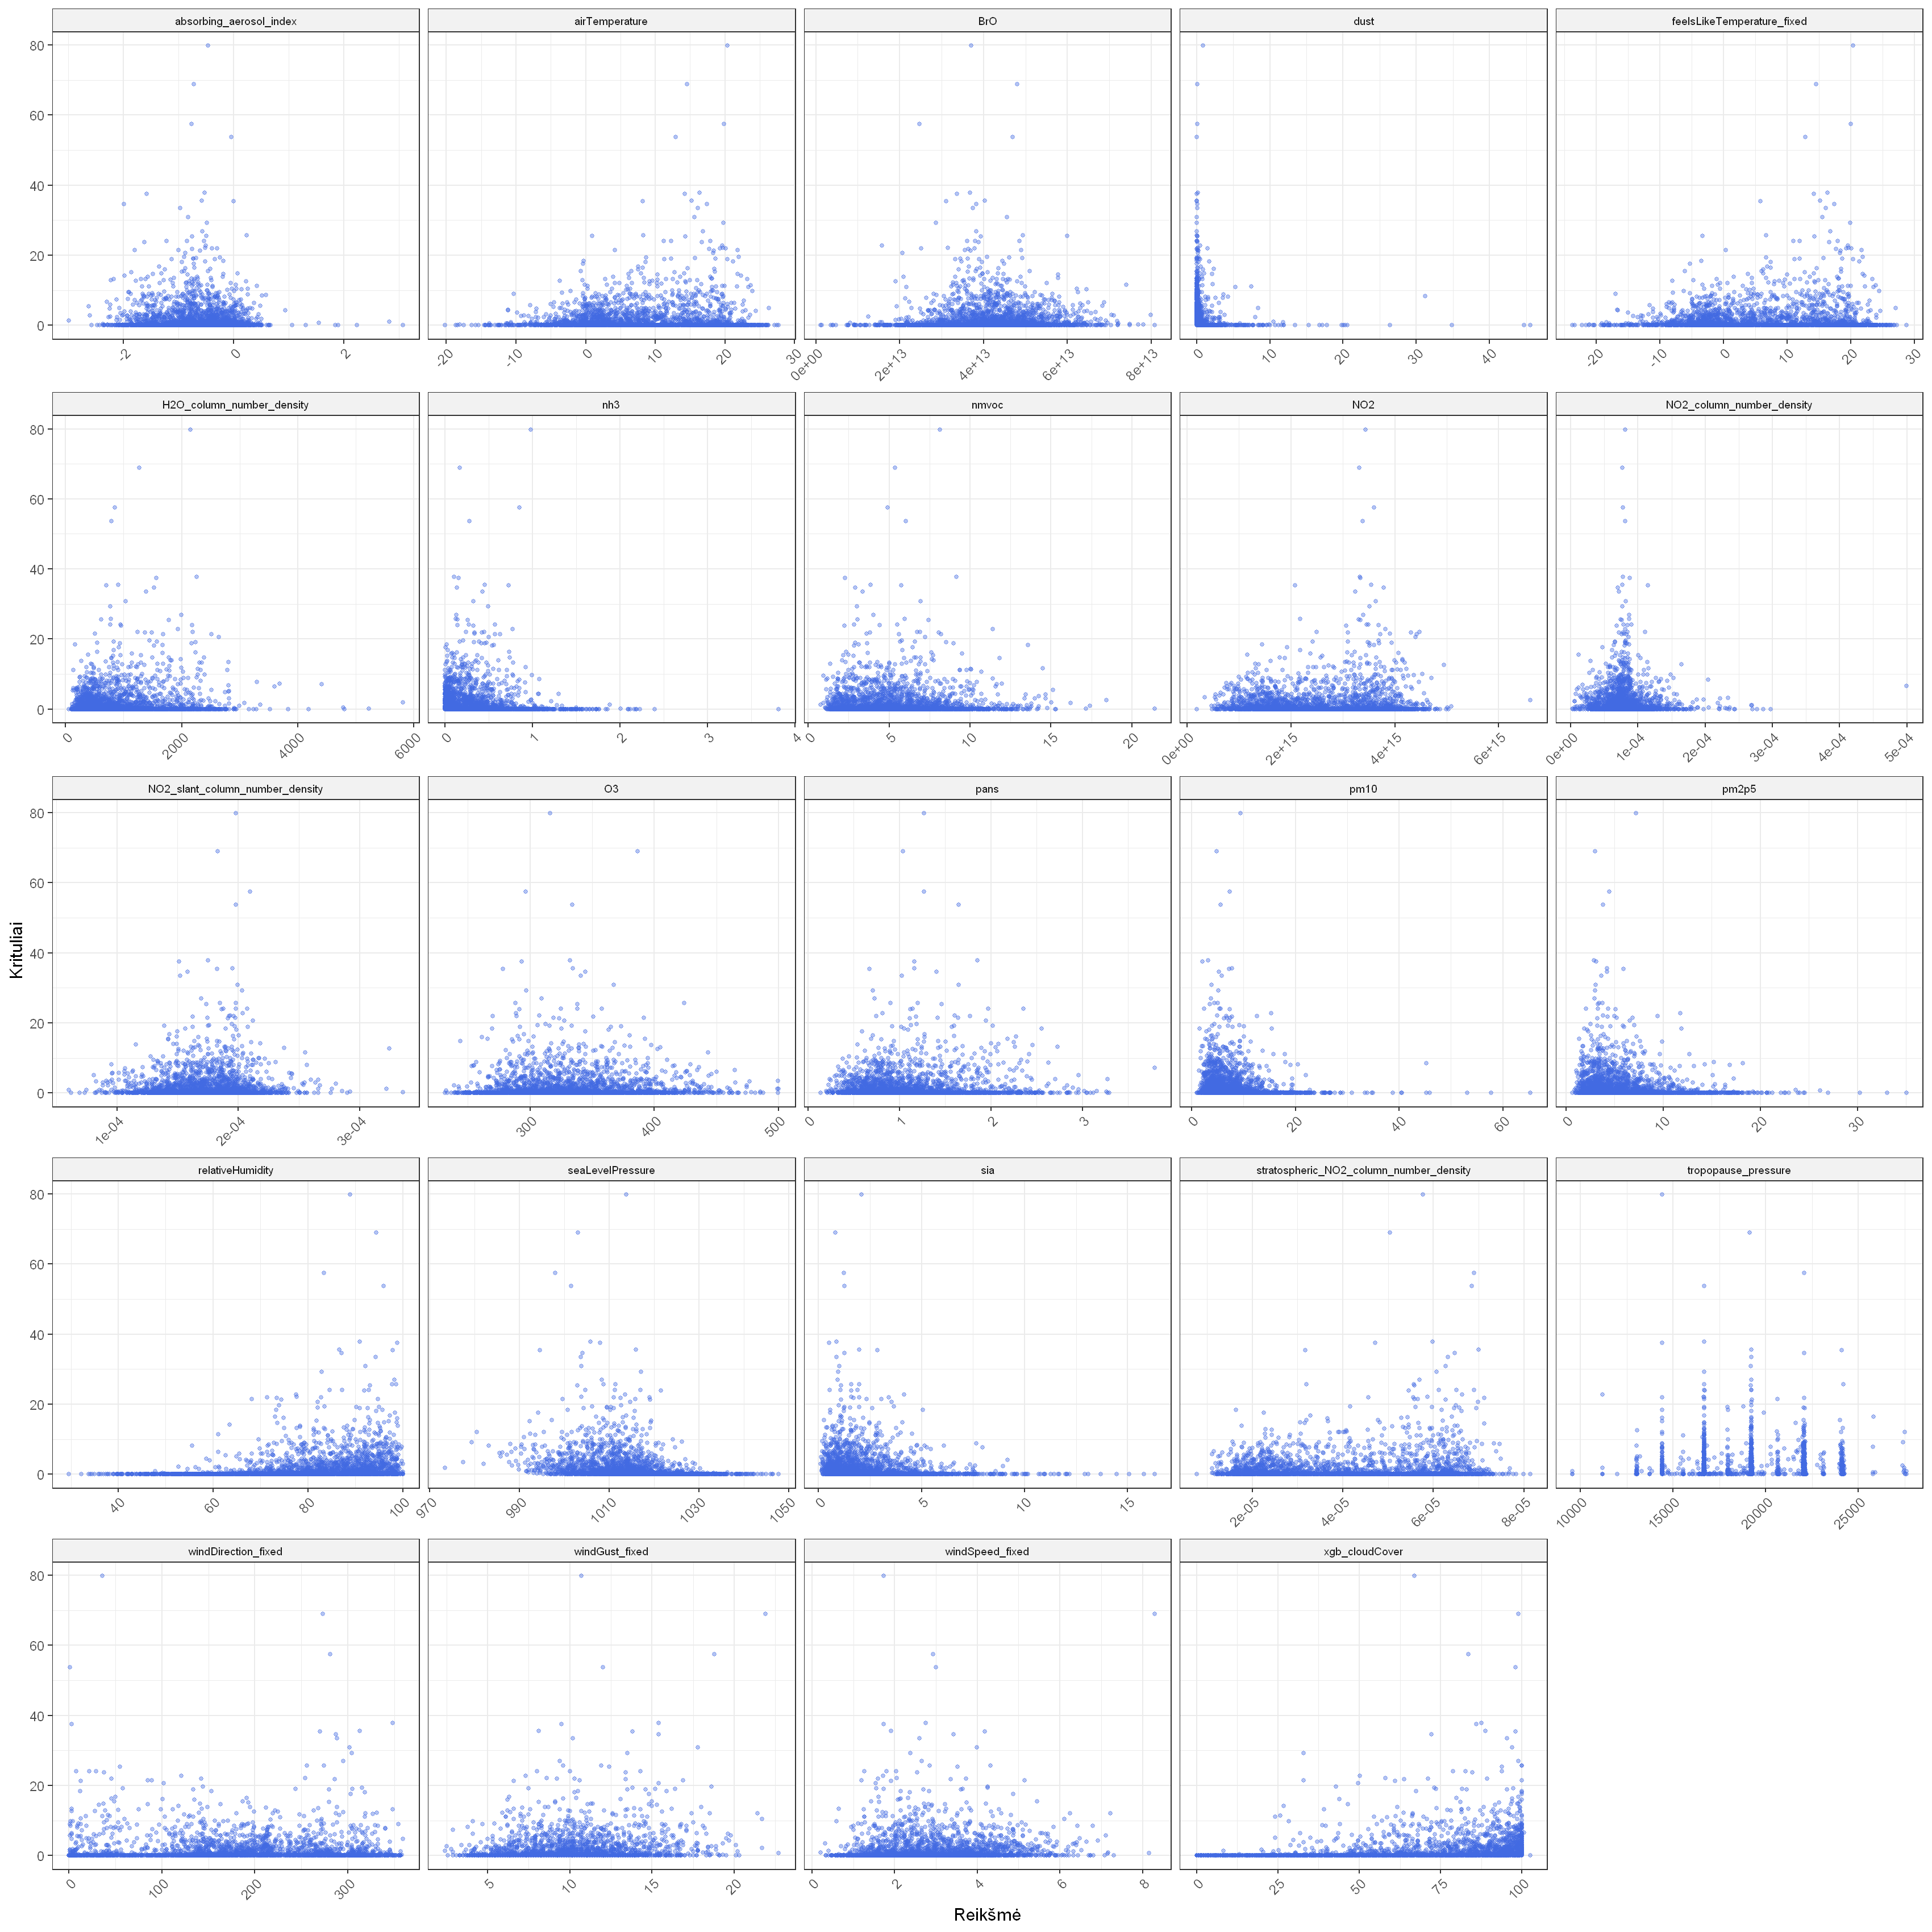

In [33]:
options(repr.plot.width = 17, repr.plot.height = 17, repr.plot.res = 200)
data_clean %>%
  dplyr::select(where(is.numeric)) %>%
  dplyr::select(-tp, -t2m, -tp_lag, -tp_error) %>%
  pivot_longer(cols = -`missforest_precipitation`, 
               names_to = "variable", 
               values_to = "value") %>%
  ggplot(aes(x = value, y = `missforest_precipitation`)) +
  geom_point(alpha = 0.4, size = 0.95, color = "royalblue") +
  facet_wrap(~variable, scales = "free_x", ncol = 5) +
  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey95"),
    strip.text = element_text(size = 7),
    axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(x = "Reikšmė",
       y = "Krituliai")

#ggsave(filename = "sklaida.png", width = 6.7, height = 4, units = "in", dpi = 300)